# Customer Segmentation from Smart-Meter Energy Data

**Context:** Energy utilities increasingly rely on smart-meter data to understand consumption behavior. Traditional clustering techniques produce statistically valid segments that often lack interpretability and strategic usability.

**Objective:** Develop a hybrid customer segmentation framework that:
1. Extracts behavioral features from synthetic smart-meter time-series data
2. Applies unsupervised clustering to identify homogeneous consumption groups
3. Utilizes a role-specialized multi-agent LLM architecture to generate stable segment naming and interpret behavioral characteristics

**Approach:** Profiles are identified using **energy consumption only**. After the profiles are created, household metadata (context information) is brought in to enrich the interpretation.

**Data:** Synthetic dataset (`hope_city_hourly_consumption_v2_2025`) — 500 households, 4.38M hourly records over one year, with `electricity_kWh` (always positive, 0.06–48.61) and `gas_kWh` columns.

# 1. Exploratory Data Analysis

---



In [1]:
import seaborn as sns
import numpy, scipy
# disregrad warning
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
print(sns.__version__, numpy.__version__, scipy.__version__)


0.13.2 2.2.6 1.15.3


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

## 1.1 Data Loading & Validation

In [3]:
df_metadata = pd.read_csv('dataset/hope_city_households_metadata.csv')

In [4]:
df_metadata.head()

,household_id,property_type,construction_age_band,floor_area_m2,insulation_quality,tenure_type,num_occupants,income_band,occupancy_pattern,children_present,heating_type,cooling_system,cooking_fuel,solar_pv,pv_capacity_kwp,ev_ownership
0,1,apartment,after 2010,69.9,medium,social housing,2,medium,working adults,no,gas boiler,none,gas,no,0.00,no
1,2,terraced,1945–1970,88.4,poor,social housing,4,high,working adults,no,gas boiler,reversible heat pump,electric,no,0.00,no
2,3,detached house,1945–1970,133.9,poor,social housing,4,high,retired,yes,gas boiler,none,gas,no,0.00,no
3,4,detached house,1990–2010,166.0,good,private rental,2,high,mixed,yes,heat pump,reversible heat pump,electric,yes,4.76,no
4,5,terraced,1945–1970,118.5,medium,owner-occupied,2,high,mixed,no,heat pump,none,electric,no,0.00,no


In [5]:
df_metadata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   household_id           500 non-null    int64  
 1   property_type          500 non-null    object 
 2   construction_age_band  500 non-null    object 
 3   floor_area_m2          500 non-null    float64
 4   insulation_quality     500 non-null    object 
 5   tenure_type            500 non-null    object 
 6   num_occupants          500 non-null    int64  
 7   income_band            500 non-null    object 
 8   occupancy_pattern      500 non-null    object 
 9   children_present       500 non-null    object 
 10  heating_type           500 non-null    object 
 11  cooling_system         500 non-null    object 
 12  cooking_fuel           500 non-null    object 
 13  solar_pv               500 non-null    object 
 14  pv_capacity_kwp        500 non-null    float64
 15  ev_own

In [6]:
df_metadata.isnull().sum().sum()

np.int64(0)

In [7]:
df_consumption = pd.read_csv('dataset/hope_city_hourly_consumption_v2_2025.csv.gz',parse_dates=["timestamp"])

In [8]:
df_consumption.head()

,household_id,timestamp,electricity_kWh,gas_kWh
0,1,2025-01-01 00:00:00,0.1064,2.2473
1,1,2025-01-01 01:00:00,0.0992,2.5255
2,1,2025-01-01 02:00:00,0.1074,2.9389
3,1,2025-01-01 03:00:00,0.1211,3.4713
4,1,2025-01-01 04:00:00,0.1473,4.9098


In [9]:
df_consumption.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4380000 entries, 0 to 4379999
Data columns (total 4 columns):
 #   Column           Dtype         
---  ------           -----         
 0   household_id     int64         
 1   timestamp        datetime64[ns]
 2   electricity_kWh  float64       
 3   gas_kWh          float64       
dtypes: datetime64[ns](1), float64(2), int64(1)
memory usage: 133.7 MB


In [10]:
df_consumption.isnull().sum().sum()

np.int64(0)

In [11]:
# zero electricity consumption records
zero_consumption = df_consumption[df_consumption['electricity_kWh'] == 0]
print(f"Number of records with zero consumption: {len(zero_consumption)}")

Number of records with zero consumption: 0


In [12]:
# Missing timestamps in the consumption data
df_consumption['timestamp'].isnull().sum()


np.int64(0)

We can verify that our dataset contain 500 households; 4,380,000 hourly rows with no missing timestamps and no NaNs

## 1.2 Global Consumption Patterns

In [13]:
df_consumption['date'] = df_consumption["timestamp"].dt.date
df_consumption["hour"] = df_consumption["timestamp"].dt.hour
df_consumption["day_of_week"] = df_consumption["timestamp"].dt.dayofweek +1 # Monday=1, Sunday=7
df_consumption["month"] = df_consumption["timestamp"].dt.month
df_consumption["is_weekend"] = (df_consumption["day_of_week"] >= 5).astype(int)

In [14]:
avg_hourly = df_consumption.groupby("hour")["electricity_kWh"].mean()
monthly_avg_electricity = df_consumption.groupby("month")["electricity_kWh"].mean()
monthly_avg_gas = df_consumption.groupby("month")["gas_kWh"].mean()
avg_daily = df_consumption.groupby("day_of_week")["electricity_kWh"].mean()

In [15]:
monthly_avg_electricity.info()

<class 'pandas.core.series.Series'>
Index: 12 entries, 1 to 12
Series name: electricity_kWh
Non-Null Count  Dtype  
--------------  -----  
12 non-null     float64
dtypes: float64(1)
memory usage: 144.0 bytes


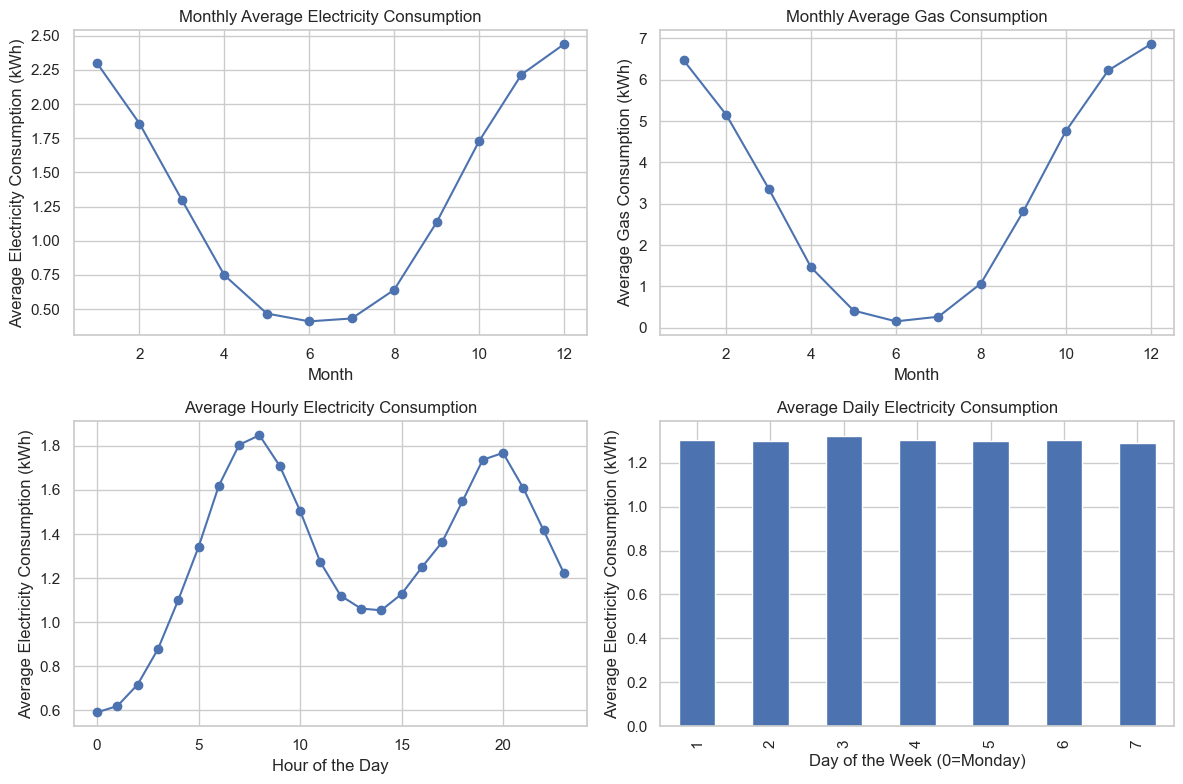

In [16]:
# monthly patterns
plt.figure(figsize=(12,8))
plt.subplot(2,2,1)
monthly_avg_electricity.plot(kind="line",marker="o")
plt.xlabel("Month")
plt.ylabel("Average Electricity Consumption (kWh)")
plt.title("Monthly Average Electricity Consumption")

plt.subplot(2,2,2)
monthly_avg_gas.plot(kind="line",marker="o")
plt.xlabel("Month")
plt.ylabel("Average Gas Consumption (kWh)")
plt.title("Monthly Average Gas Consumption")

plt.subplot(2,2,3)
avg_hourly.plot(kind="line",marker="o")
plt.xlabel("Hour of the Day")
plt.ylabel("Average Electricity Consumption (kWh)")
plt.title("Average Hourly Electricity Consumption")

plt.subplot(2,2,4)
avg_daily.plot(kind="bar")
plt.xlabel("Day of the Week (0=Monday)")
plt.ylabel("Average Electricity Consumption (kWh)")
plt.title("Average Daily Electricity Consumption")

plt.tight_layout()

In [17]:
from plotly.subplots import make_subplots

# mean accross all households for each month, day of the week and hour
avg_households_consumption = df_consumption.groupby(["month", "day_of_week", "hour"])[["electricity_kWh", "gas_kWh"]].mean().reset_index()

import plotly.graph_objects as go
fig = make_subplots(rows=3, 
                    cols=2, 
                    subplot_titles=("Monthly Electricity Consumption distribution", 
                                    "Monthly  Gas Consumption distribution", 
                                    "Hourly Electricity Consumption distribution", 
                                    "Daily Electricity Consumption",
                                    "mean electricity consumption during the week (24*7)"),
                     vertical_spacing=0.15,
                    horizontal_spacing=0.12                                
                    )

# monthly boxplots for electricity and gas + mean  lines 
fig.add_trace(
    go.Box(y=avg_households_consumption["electricity_kWh"], 
           x=avg_households_consumption["month"],
           name="Month",
            boxpoints='outliers',
            marker=dict(
            color='blue',
            outliercolor='black',
            # line=dict(outliercolor='black', outlierwidth=2)
        ),
        showlegend=False),
    row=1, col=1)
fig.add_trace(go.Scatter(x=monthly_avg_electricity.index,
                         y=monthly_avg_electricity.values,
                         mode='lines+markers',
                         name='Mean Electricity',
                         line=dict(color='red', width=2),
                         showlegend=False
                         ),
              row=1, col=1)
# monthly boxplots for gas + mean or average lines
fig.add_trace(
    go.Box(y=avg_households_consumption["gas_kWh"],
           x=avg_households_consumption["month"],
           name="Month",
           boxpoints='outliers',
           marker=dict(
        color='green',
        outliercolor='black',
),
        showlegend=False),
    row=1, col=2)

fig.add_trace(go.Scatter(x=monthly_avg_gas.index,
                         y=monthly_avg_gas.values,
                         mode='lines+markers',
                         name='Mean Gas',
                         line=dict(color='red', width=2,),
                         showlegend=False
                         ),
              row=1, col=2
              )
# weekly boxplots for electricity + mean or average lines
fig.add_trace(
    go.Box(y=avg_households_consumption["electricity_kWh"],
           x=avg_households_consumption["day_of_week"],
           name="Day of Week",
           boxpoints='outliers',
           marker=dict(
        color='orange',
        outliercolor='black',
),
        showlegend=False),
    row=2, col=1)
fig.add_trace(go.Scatter(x=avg_daily.index,
                         y=avg_daily.values,
                         mode='lines+markers',
                         name='Mean Daily Electricity',
                         line=dict(color='red', width=2),
                         showlegend=False
                         ),
              row=2, col=1
              )
# hourly boxplots for electricity + mean or average lines
fig.add_trace(
    go.Box(y=avg_households_consumption["electricity_kWh"],
           x=avg_households_consumption["hour"],
           name="Hour of Day",
           boxpoints='outliers',
           marker=dict(
        color='purple',
        outliercolor='black',
),
        showlegend=False),
    row=2, col=2)
fig.add_trace(go.Scatter(x=avg_hourly.index,
                         y=avg_hourly.values,
                         mode='lines+markers',
                         name='Mean Hourly Electricity',
                         line=dict(color='red', width=2),
                         showlegend=False
                         ),
              row=2, col=2
              )
# mean electricity consumption evolution during the week (24*7)
mean_weekly = df_consumption.groupby(["day_of_week", "hour"])["electricity_kWh"].mean().reset_index()

mean_weekly["hour_week"] = (mean_weekly["day_of_week"]-1) * 24 + mean_weekly["hour"]


fig.add_trace(go.Scatter(x=mean_weekly["hour_week"],
                         y=mean_weekly["electricity_kWh"],
                         mode='lines',
                        name='Day and hour',
                        marker_color='coral',
                        showlegend=False
                         ),
              row=3, col=1
              )

# Set custom tick values and labels for the x-axis of the subplot in row 3, col 1
fig.update_xaxes(
    tickvals=[i * 24 for i in range(7)],
    ticktext=["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"],
    row=3, col=1
)

# Update layout
fig.update_layout(
    height=800,
    width=1200,
    title_text="Electricity and Gas consumption Distribution and Mean Evolution (Île-de-France)",
    margin=dict(l=30, r=30, t=60, b=30)
)

fig.update_xaxes(title_text="Month", row=1, col=1)
fig.update_xaxes(title_text="Month", row=1, col=2)
fig.update_xaxes(title_text="Day of Week (1=Monday)", row=2, col=1)
fig.update_xaxes(title_text="Hour of Day", row=2, col=2)



fig.update_yaxes(title_text="Electricity Consumption (kWh)", row=1, col=1)
fig.update_yaxes(title_text="Gas Consumption (kWh)", row=1, col=2)
fig.update_yaxes(title_text="Electricity Consumption (kWh)", row=2, col=1)
fig.update_yaxes(title_text="Electricity Consumption (kWh)", row=2, col=2)
fig.update_yaxes(title_text="Electricity Consumption (kWh)", row=3, col=1)


As we can see from these distributions, the synthetic data is representative of real-world behavior, exhibiting actual patterns of European gas and electricity consumption. The data reflects seasonal variations across months (January to December), with notable differences between winter and summer, as well as temporal patterns throughout the day, week, and weekends.

**Observation on mean values:** Notice that the **red line (mean) often appears far outside the boxes**, especially in the monthly and hourly distributions. This is completely normal for skewed data—the mean gets pulled toward extreme values by the long tail. This visual confirms the presence of strong skewness in the data, validating our preprocessing strategy.

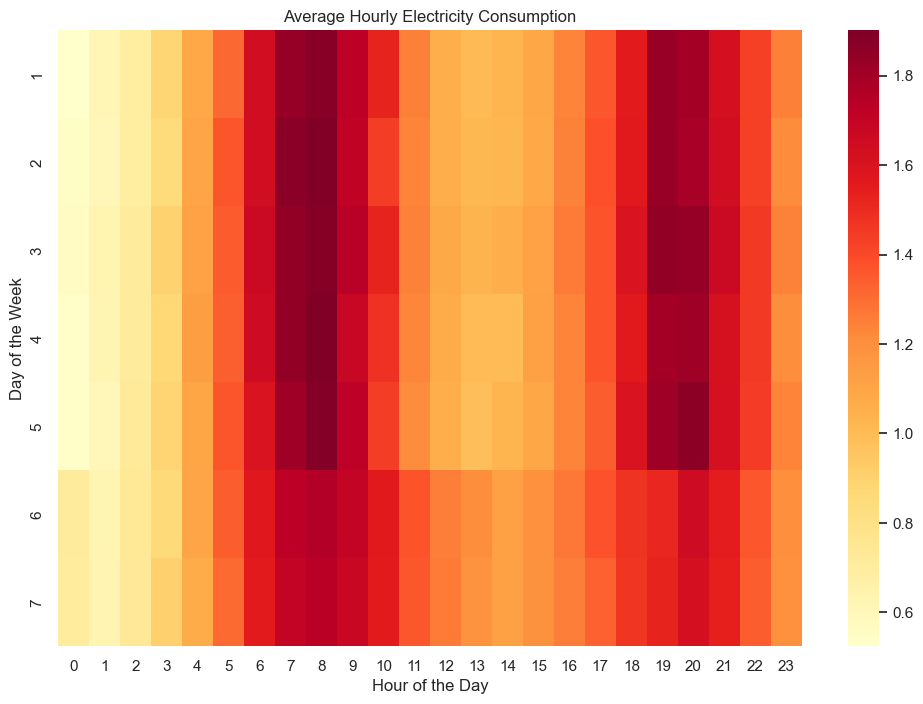

In [18]:
# 7*24 hours distribution of electricity consumption mean across all households
hourly_daily_avg = df_consumption.groupby(["day_of_week", "hour"])["electricity_kWh"].mean().unstack()
plt.figure(figsize=(12, 8))
sns.heatmap(hourly_daily_avg, cmap="YlOrRd")
plt.xlabel("Hour of the Day")
plt.ylabel("Day of the Week")
plt.title("Average Hourly Electricity Consumption")
plt.show()

In [19]:
# Definining seasonal masks
winter_months = [12, 1, 2]
summer_months = [6, 7, 8]

## 1.3 Household-Level Distributions

Exploratory summary statistics per household. These features are **not used directly in the clustering pipeline** — they serve as a quick sanity check that variance exists across households before building the full feature set.

In [20]:
hh_stats = df_consumption.groupby("household_id").agg(
    mean_elec=("electricity_kWh", "mean"),
    std_elec=("electricity_kWh", "std"),
    max_elec=("electricity_kWh", "max"),
    annual_elec=("electricity_kWh", "sum"),
    annual_gas=("gas_kWh", "sum")
).reset_index()

# Peak-to-average ratio
hh_stats["peak_to_avg"] = hh_stats["max_elec"] / hh_stats["mean_elec"]

### Seasonal ratio

In [21]:
# Winter vs Summer electricity
winter = df_consumption[df_consumption["month"].isin(winter_months)]
summer = df_consumption[df_consumption["month"].isin(summer_months)]

winter_sum = winter.groupby("household_id")["electricity_kWh"].sum()
summer_sum = summer.groupby("household_id")["electricity_kWh"].sum()

hh_stats["winter_summer_ratio"] = (
    winter_sum / summer_sum
).replace([np.inf, -np.inf], np.nan)

### Night vs Day ratio

In [22]:
night = df_consumption[(df_consumption["hour"] >= 0) & (df_consumption["hour"] <= 6)]
day = df_consumption[(df_consumption["hour"] >= 8) & (df_consumption["hour"] <= 20)]

night_mean = night.groupby("household_id")["electricity_kWh"].mean()
day_mean = day.groupby("household_id")["electricity_kWh"].mean()

hh_stats["night_day_ratio"] = night_mean / day_mean

### Weekend vs Weekday ratio

In [23]:
weekend = df_consumption[df_consumption["is_weekend"] == 1]
weekday = df_consumption[df_consumption["is_weekend"] == 0]

weekend_mean = weekend.groupby("household_id")["electricity_kWh"].mean()
weekday_mean = weekday.groupby("household_id")["electricity_kWh"].mean()

hh_stats["weekend_weekday_ratio"] = weekend_mean / weekday_mean

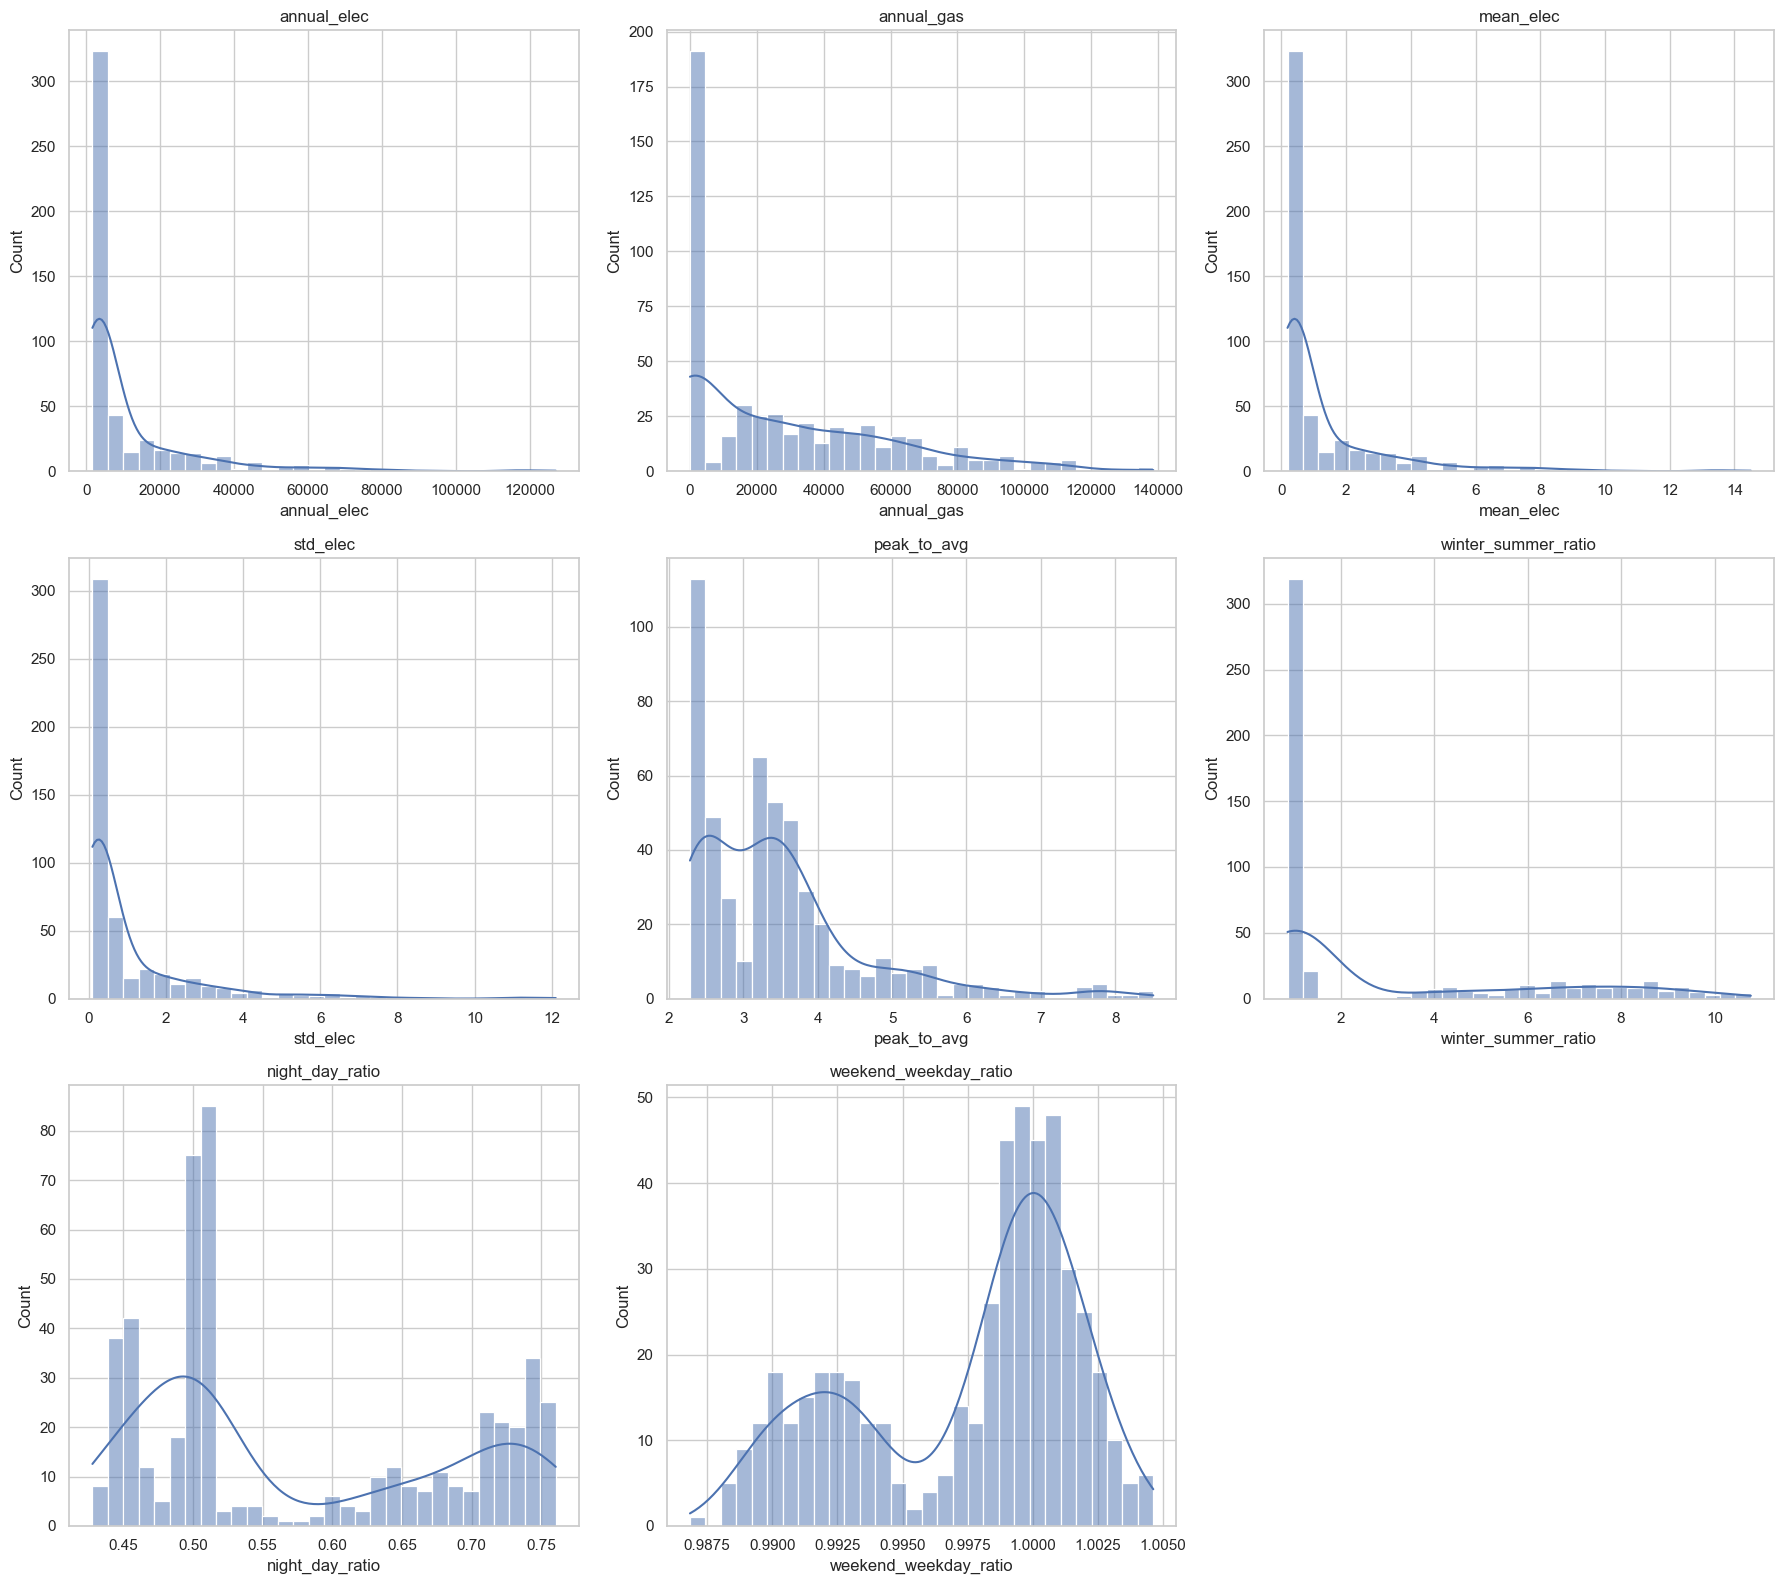

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

features_to_plot = [
    "annual_elec",
    "annual_gas",
    "mean_elec",
    "std_elec",
    "peak_to_avg",
    "winter_summer_ratio",
    "night_day_ratio",
    "weekend_weekday_ratio",
]

plt.figure(figsize=(18, 16))

for i, feature in enumerate(features_to_plot):
    plt.subplot(3, 3, i+1)
    sns.histplot(hh_stats[feature].dropna(), bins=30, kde=True)
    plt.title(feature)

plt.tight_layout()
plt.show()

The distributions show strong variance in magnitude features across households, and they are right-skewed. This confirms that meaningful segmentation based on energy consumption is feasible.

# 2. Feature Engineering for Clustering

---

## 2.1 Dataset Check
The dataset contains only positive electricity values (range: 0.06–48.61 kWh). No import/export split is needed — `electricity_kWh` can be used directly for all volume, proportion, and ratio features.

In [25]:
# No negative electricity in this dataset — import/export split not needed
print(f"electricity_kWh range: [{df_consumption['electricity_kWh'].min():.4f}, {df_consumption['electricity_kWh'].max():.4f}]")
print(f"Negative records: {(df_consumption['electricity_kWh'] < 0).sum()}")

electricity_kWh range: [0.0610, 48.6112]
Negative records: 0


## 2.2 Time-Period & Daily Aggregation

In [26]:
df_consumption["is_overnight"] = df_consumption["hour"].between(0, 5)
df_consumption["is_morning"] = df_consumption["hour"].between(6, 10)
df_consumption["is_9_to_5"] = df_consumption["hour"].between(9, 16)
df_consumption["is_lunch"] = df_consumption["hour"].between(11, 13)
df_consumption["is_dinner"] = df_consumption["hour"].between(17, 20)
df_consumption["is_evening_peak"] = df_consumption["hour"].between(18, 21)

winter_months = [12, 1, 2]
summer_months = [6, 7, 8]
period_cols = [
    "is_overnight", "is_morning", "is_9_to_5",
    "is_lunch", "is_dinner", "is_evening_peak"
]
df_consumption[period_cols].mean()


is_overnight       0.250000
is_morning         0.208333
is_9_to_5          0.333333
is_lunch           0.125000
is_dinner          0.166667
is_evening_peak    0.166667
dtype: float64

In [27]:
daily = df_consumption.groupby(["household_id", "date"]).agg(
    daily_electricity_kwh=("electricity_kWh", "sum"),
    daily_gas_kwh=("gas_kWh", "sum"),
    month=("month", "first"),
    is_weekend=("is_weekend", "max")
).reset_index()

In [28]:
daily.head()

,household_id,date,daily_electricity_kwh,daily_gas_kwh,month,is_weekend
0,1,2025-01-01,6.3747,121.5785,1,0
1,1,2025-01-02,6.4582,123.1293,1,0
2,1,2025-01-03,6.3037,117.3140,1,1
3,1,2025-01-04,6.4150,120.5646,1,1
4,1,2025-01-05,6.2457,116.5935,1,1


In [29]:
period_defs = {
    "9_to_5": "is_9_to_5",
    "overnight": "is_overnight",
    "morning": "is_morning",
    "lunch": "is_lunch",
    "dinner": "is_dinner",
    "evening_peak": "is_evening_peak",
}

In [30]:
for period_name, period_col in period_defs.items():
    tmp = (
        df_consumption[df_consumption[period_col]]
        .groupby(["household_id", "date"])
        .agg(
            **{
                f"electricity_{period_name}_kwh": ("electricity_kWh", "sum"),
                f"gas_{period_name}_kwh": ("gas_kWh", "sum"),
            }
        )
        .reset_index()
    )
    
    daily = daily.merge(tmp, on=["household_id", "date"], how="left")

In [31]:
daily.isnull().sum().sum()

np.int64(0)

In [32]:
zero_consumption_daily = daily[daily["daily_gas_kwh"] == 0]
print(f"Number of daily records with zero gas consumption: {len(zero_consumption_daily)}")

Number of daily records with zero gas consumption: 51465


In [33]:
# daily proportions features
for period_name in period_defs.keys():
    daily[f"prop_daily_electricity_{period_name}"] = np.where(
        daily["daily_electricity_kwh"] > 0,
        daily[f"electricity_{period_name}_kwh"] / daily["daily_electricity_kwh"],
        0
    )
    
    daily[f"prop_daily_gas_{period_name}"] = np.where(
        daily["daily_gas_kwh"] > 0,
        daily[f"gas_{period_name}_kwh"] / daily["daily_gas_kwh"],
        0
    )



In [34]:
daily[[c for c in daily.columns if "prop_daily" in c]].head()

,prop_daily_electricity_9_to_5,prop_daily_gas_9_to_5,prop_daily_electricity_overnight,prop_daily_gas_overnight,prop_daily_electricity_morning,prop_daily_gas_morning,prop_daily_electricity_lunch,prop_daily_gas_lunch,prop_daily_electricity_dinner,prop_daily_gas_dinner,prop_daily_electricity_evening_peak,prop_daily_gas_evening_peak
0,0.254945,0.346962,0.122218,0.180367,0.245690,0.250977,0.072349,0.114862,0.275464,0.196332,0.302085,0.192127
1,0.248041,0.330722,0.126614,0.192915,0.252408,0.258960,0.071320,0.115873,0.278592,0.201513,0.304837,0.199166
2,0.252090,0.340536,0.121833,0.190494,0.251947,0.265169,0.073909,0.113442,0.282564,0.190641,0.314831,0.195461
3,0.343507,0.325325,0.128090,0.183555,0.215869,0.264627,0.136041,0.118973,0.244100,0.194957,0.263102,0.194993
4,0.347551,0.332066,0.130618,0.193158,0.217830,0.264562,0.132747,0.112352,0.240646,0.188608,0.257681,0.198430


## 2.3 Inter-Day Variability

Mean of the absolute differences in gas / electricity usage between consecutive daily average usage. For `pc_diffs`, we calculate the mean of the percentage differences between consecutive days.

In [35]:
def interday_features(df, value_col, prefix):
    temp = df.sort_values(["household_id", "date"]).copy()
    temp["prev"] = temp.groupby("household_id")[value_col].shift(1)
    temp["abs_diff"] = (temp[value_col] - temp["prev"]).abs()
    temp["pc_diff"] = np.where(
        temp["prev"].abs() > 1e-9,
        temp["abs_diff"] / temp["prev"].abs(),
        np.nan
    )
    
    out = temp.groupby("household_id").agg(
        **{
            f"{prefix}_avg_mean_abs_diffs_over_year": ("abs_diff", "mean"),
            f"{prefix}_avg_mean_pc_diffs_over_year": ("pc_diff", "mean"),
        }
    ).reset_index()
    
    return out

In [36]:
interday_e = interday_features(daily, "daily_electricity_kwh", "electricity")
interday_g = interday_features(daily, "daily_gas_kwh", "gas")

interday_e.head(), interday_g.head()

(   household_id  electricity_avg_mean_abs_diffs_over_year  \
 0             1                                  0.100671   
 1             2                                  0.218700   
 2             3                                  0.170981   
 3             4                                  2.491324   
 4             5                                  1.949429   
 
    electricity_avg_mean_pc_diffs_over_year  
 0                                 0.016771  
 1                                 0.022681  
 2                                 0.014819  
 3                                 0.048770  
 4                                 0.046581  ,
    household_id  gas_avg_mean_abs_diffs_over_year  \
 0             1                          1.946137   
 1             2                          3.921265   
 2             3                          8.553633   
 3             4                          0.000000   
 4             5                          0.000000   
 
    gas_avg_mean_pc_dif

## 2.4 Household-Level Aggregation

In [37]:
features = daily.groupby("household_id").agg(
    avg_daily_electricity_usage=("daily_electricity_kwh", "mean"),
    avg_daily_gas_usage=("daily_gas_kwh", "mean"),

    avg_daily_electricity_9_to_5=("electricity_9_to_5_kwh", "mean"),
    avg_prop_daily_electricity_9_to_5=("prop_daily_electricity_9_to_5", "mean"),
    avg_daily_gas_9_to_5=("gas_9_to_5_kwh", "mean"),
    avg_prop_daily_gas_9_to_5=("prop_daily_gas_9_to_5", "mean"),

    avg_daily_electricity_overnight=("electricity_overnight_kwh", "mean"),
    prop_daily_electricity_overnight=("prop_daily_electricity_overnight", "mean"),
    avg_daily_gas_overnight=("gas_overnight_kwh", "mean"),
    prop_daily_gas_overnight=("prop_daily_gas_overnight", "mean"),

    avg_daily_electricity_morning=("electricity_morning_kwh", "mean"),
    prop_daily_electricity_morning=("prop_daily_electricity_morning", "mean"),
    avg_daily_gas_morning=("gas_morning_kwh", "mean"),
    prop_daily_gas_morning=("prop_daily_gas_morning", "mean"),

    avg_daily_electricity_lunch=("electricity_lunch_kwh", "mean"),
    prop_daily_electricity_lunch=("prop_daily_electricity_lunch", "mean"),
    avg_daily_gas_lunch=("gas_lunch_kwh", "mean"),
    prop_daily_gas_lunch=("prop_daily_gas_lunch", "mean"),

    avg_daily_electricity_dinner=("electricity_dinner_kwh", "mean"),
    prop_daily_electricity_dinner=("prop_daily_electricity_dinner", "mean"),
    avg_daily_gas_dinner=("gas_dinner_kwh", "mean"),
    prop_daily_gas_dinner=("prop_daily_gas_dinner", "mean"),

    std_daily_electricity_usage=("daily_electricity_kwh", "std"),
    std_daily_gas_usage=("daily_gas_kwh", "std"),

    evening_peak_share_electricity=("prop_daily_electricity_evening_peak", "mean"),
).reset_index()

## 2.5 Winter/Summer Ratios

In [38]:
def seasonal_ratio(df, value_col, out_name):
    winter = (
        df[df["month"].isin(winter_months)]
        .groupby("household_id")[value_col]
        .mean()
    )
    summer = (
        df[df["month"].isin(summer_months)]
        .groupby("household_id")[value_col]
        .mean()
    )
    
    ratio = (winter / summer.replace(0, np.nan)).rename(out_name)
    return ratio.reset_index()

In [39]:
ratio_e = seasonal_ratio(
    daily,
    "daily_electricity_kwh",
    "ratio_winter_summer_electricity_usage"
)

ratio_g = seasonal_ratio(
    daily,
    "daily_gas_kwh",
    "ratio_winter_summer_gas_usage"
)

ratio_total = seasonal_ratio(
    daily.assign(daily_total_kwh=daily["daily_electricity_kwh"] + daily["daily_gas_kwh"]),
    "daily_total_kwh",
    "winter_summer_total_ratio"
)

## 2.6 Weekend Averages & Ratios

In [40]:
weekday_avg = (
    daily[daily["is_weekend"] == 0]
    .groupby("household_id")[["daily_electricity_kwh", "daily_gas_kwh"]]
    .mean()
    .rename(columns={
        "daily_electricity_kwh": "avg_daily_electricity_weekday",
        "daily_gas_kwh": "avg_daily_gas_weekday"
    })
)

weekend_avg = (
    daily[daily["is_weekend"] == 1]
    .groupby("household_id")[["daily_electricity_kwh", "daily_gas_kwh"]]
    .mean()
    .rename(columns={
        "daily_electricity_kwh": "avg_daily_electricity_weekend",
        "daily_gas_kwh": "avg_daily_gas_weekend"
    })
)

In [41]:
week_ratios = weekend_avg.join(weekday_avg)

week_ratios["weekend_weekday_ratio_electricity"] = (
    week_ratios["avg_daily_electricity_weekend"] /
    week_ratios["avg_daily_electricity_weekday"].replace(0, np.nan)
)

week_ratios["weekend_weekday_ratio_gas"] = (
    week_ratios["avg_daily_gas_weekend"] /
    week_ratios["avg_daily_gas_weekday"].replace(0, np.nan)
)

week_ratios = week_ratios.reset_index()
week_ratios.head()

,household_id,avg_daily_electricity_weekend,avg_daily_gas_weekend,avg_daily_electricity_weekday,avg_daily_gas_weekday,weekend_weekday_ratio_electricity,weekend_weekday_ratio_gas
0,1,5.981769,56.099634,6.002340,56.758305,0.996573,0.988395
1,2,9.517838,115.615661,9.510943,116.740793,1.000725,0.990362
2,3,11.532001,252.125873,11.528071,254.612721,1.000341,0.990233
3,4,74.153587,0.000000,74.898290,0.000000,0.990057,NaN
4,5,55.594583,0.000000,56.031353,0.000000,0.992205,NaN


## 2.7 Peak-to-Average Electricity

In [42]:
hourly_stats = df_consumption.groupby("household_id").agg(
    mean_hourly_electricity=("electricity_kWh", "mean"),
    max_hourly_electricity=("electricity_kWh", "max")
).reset_index()

hourly_stats["peak_to_avg_electricity"] = (
    hourly_stats["max_hourly_electricity"] /
    hourly_stats["mean_hourly_electricity"].replace(0, np.nan)
)

hourly_stats = hourly_stats[["household_id", "peak_to_avg_electricity"]]
hourly_stats.head()

,household_id,peak_to_avg_electricity
0,1,2.362140
1,2,4.644914
2,3,2.352176
3,4,3.887852
4,5,3.813635


## 2.8 Feature Merge & NaN Handling

In [43]:
for df in [ratio_e, ratio_g, ratio_total, interday_e, interday_g, week_ratios, hourly_stats]:
    features = features.merge(df, on="household_id", how="left")

In [44]:
features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 40 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   household_id                              500 non-null    int64  
 1   avg_daily_electricity_usage               500 non-null    float64
 2   avg_daily_gas_usage                       500 non-null    float64
 3   avg_daily_electricity_9_to_5              500 non-null    float64
 4   avg_prop_daily_electricity_9_to_5         500 non-null    float64
 5   avg_daily_gas_9_to_5                      500 non-null    float64
 6   avg_prop_daily_gas_9_to_5                 500 non-null    float64
 7   avg_daily_electricity_overnight           500 non-null    float64
 8   prop_daily_electricity_overnight          500 non-null    float64
 9   avg_daily_gas_overnight                   500 non-null    float64
 10  prop_daily_gas_overnight              

In [45]:
# columns with NaN values:
features.isnull().sum()[features.isnull().sum() > 0]

ratio_winter_summer_gas_usage      141
gas_avg_mean_pc_diffs_over_year    141
weekend_weekday_ratio_gas          141
dtype: int64

We have 3 variables with NaN values. The NaNs occur because 141 households have zero or near-zero gas consumption, causing division-by-zero errors when calculating ratios.

To handle them, I will:
1. Create a gas-usage flag to separate households with and without gas consumption
2. Impute gas-specific ratios with 1 (neutral value for ratios, representing equilibrium)
3. Impute the percentage variable with 0 (representing zero variability for non-gas households)

In [46]:
features["has_gas_usage"] = (features["avg_daily_gas_usage"] > 0).astype(int)

features["ratio_winter_summer_gas_usage"] = features["ratio_winter_summer_gas_usage"].fillna(1)
features["weekend_weekday_ratio_gas"] = features["weekend_weekday_ratio_gas"].fillna(1)
features["gas_avg_mean_pc_diffs_over_year"] = features["gas_avg_mean_pc_diffs_over_year"].fillna(0)

# 3. Data Preprocessing for Clustering

---


## Step 1: Check for Skewness


Skewness of features (sorted by magnitude):
electricity_avg_mean_abs_diffs_over_year    3.129870
avg_daily_electricity_overnight             3.093670
avg_daily_electricity_dinner                3.080045
avg_daily_electricity_weekday               3.077657
avg_daily_electricity_usage                 3.075258
avg_daily_electricity_weekend               3.072023
avg_daily_electricity_9_to_5                3.069190
avg_daily_electricity_lunch                 3.058336
avg_daily_electricity_morning               3.046755
std_daily_electricity_usage                 3.002839
prop_daily_gas_dinner                       2.205098
peak_to_avg_electricity                     1.746811
electricity_avg_mean_pc_diffs_over_year     1.287745
ratio_winter_summer_electricity_usage       1.163189
winter_summer_total_ratio                   1.091376
gas_avg_mean_abs_diffs_over_year            1.019136
avg_daily_gas_overnight                     1.012353
std_daily_gas_usage                         1.011673
av

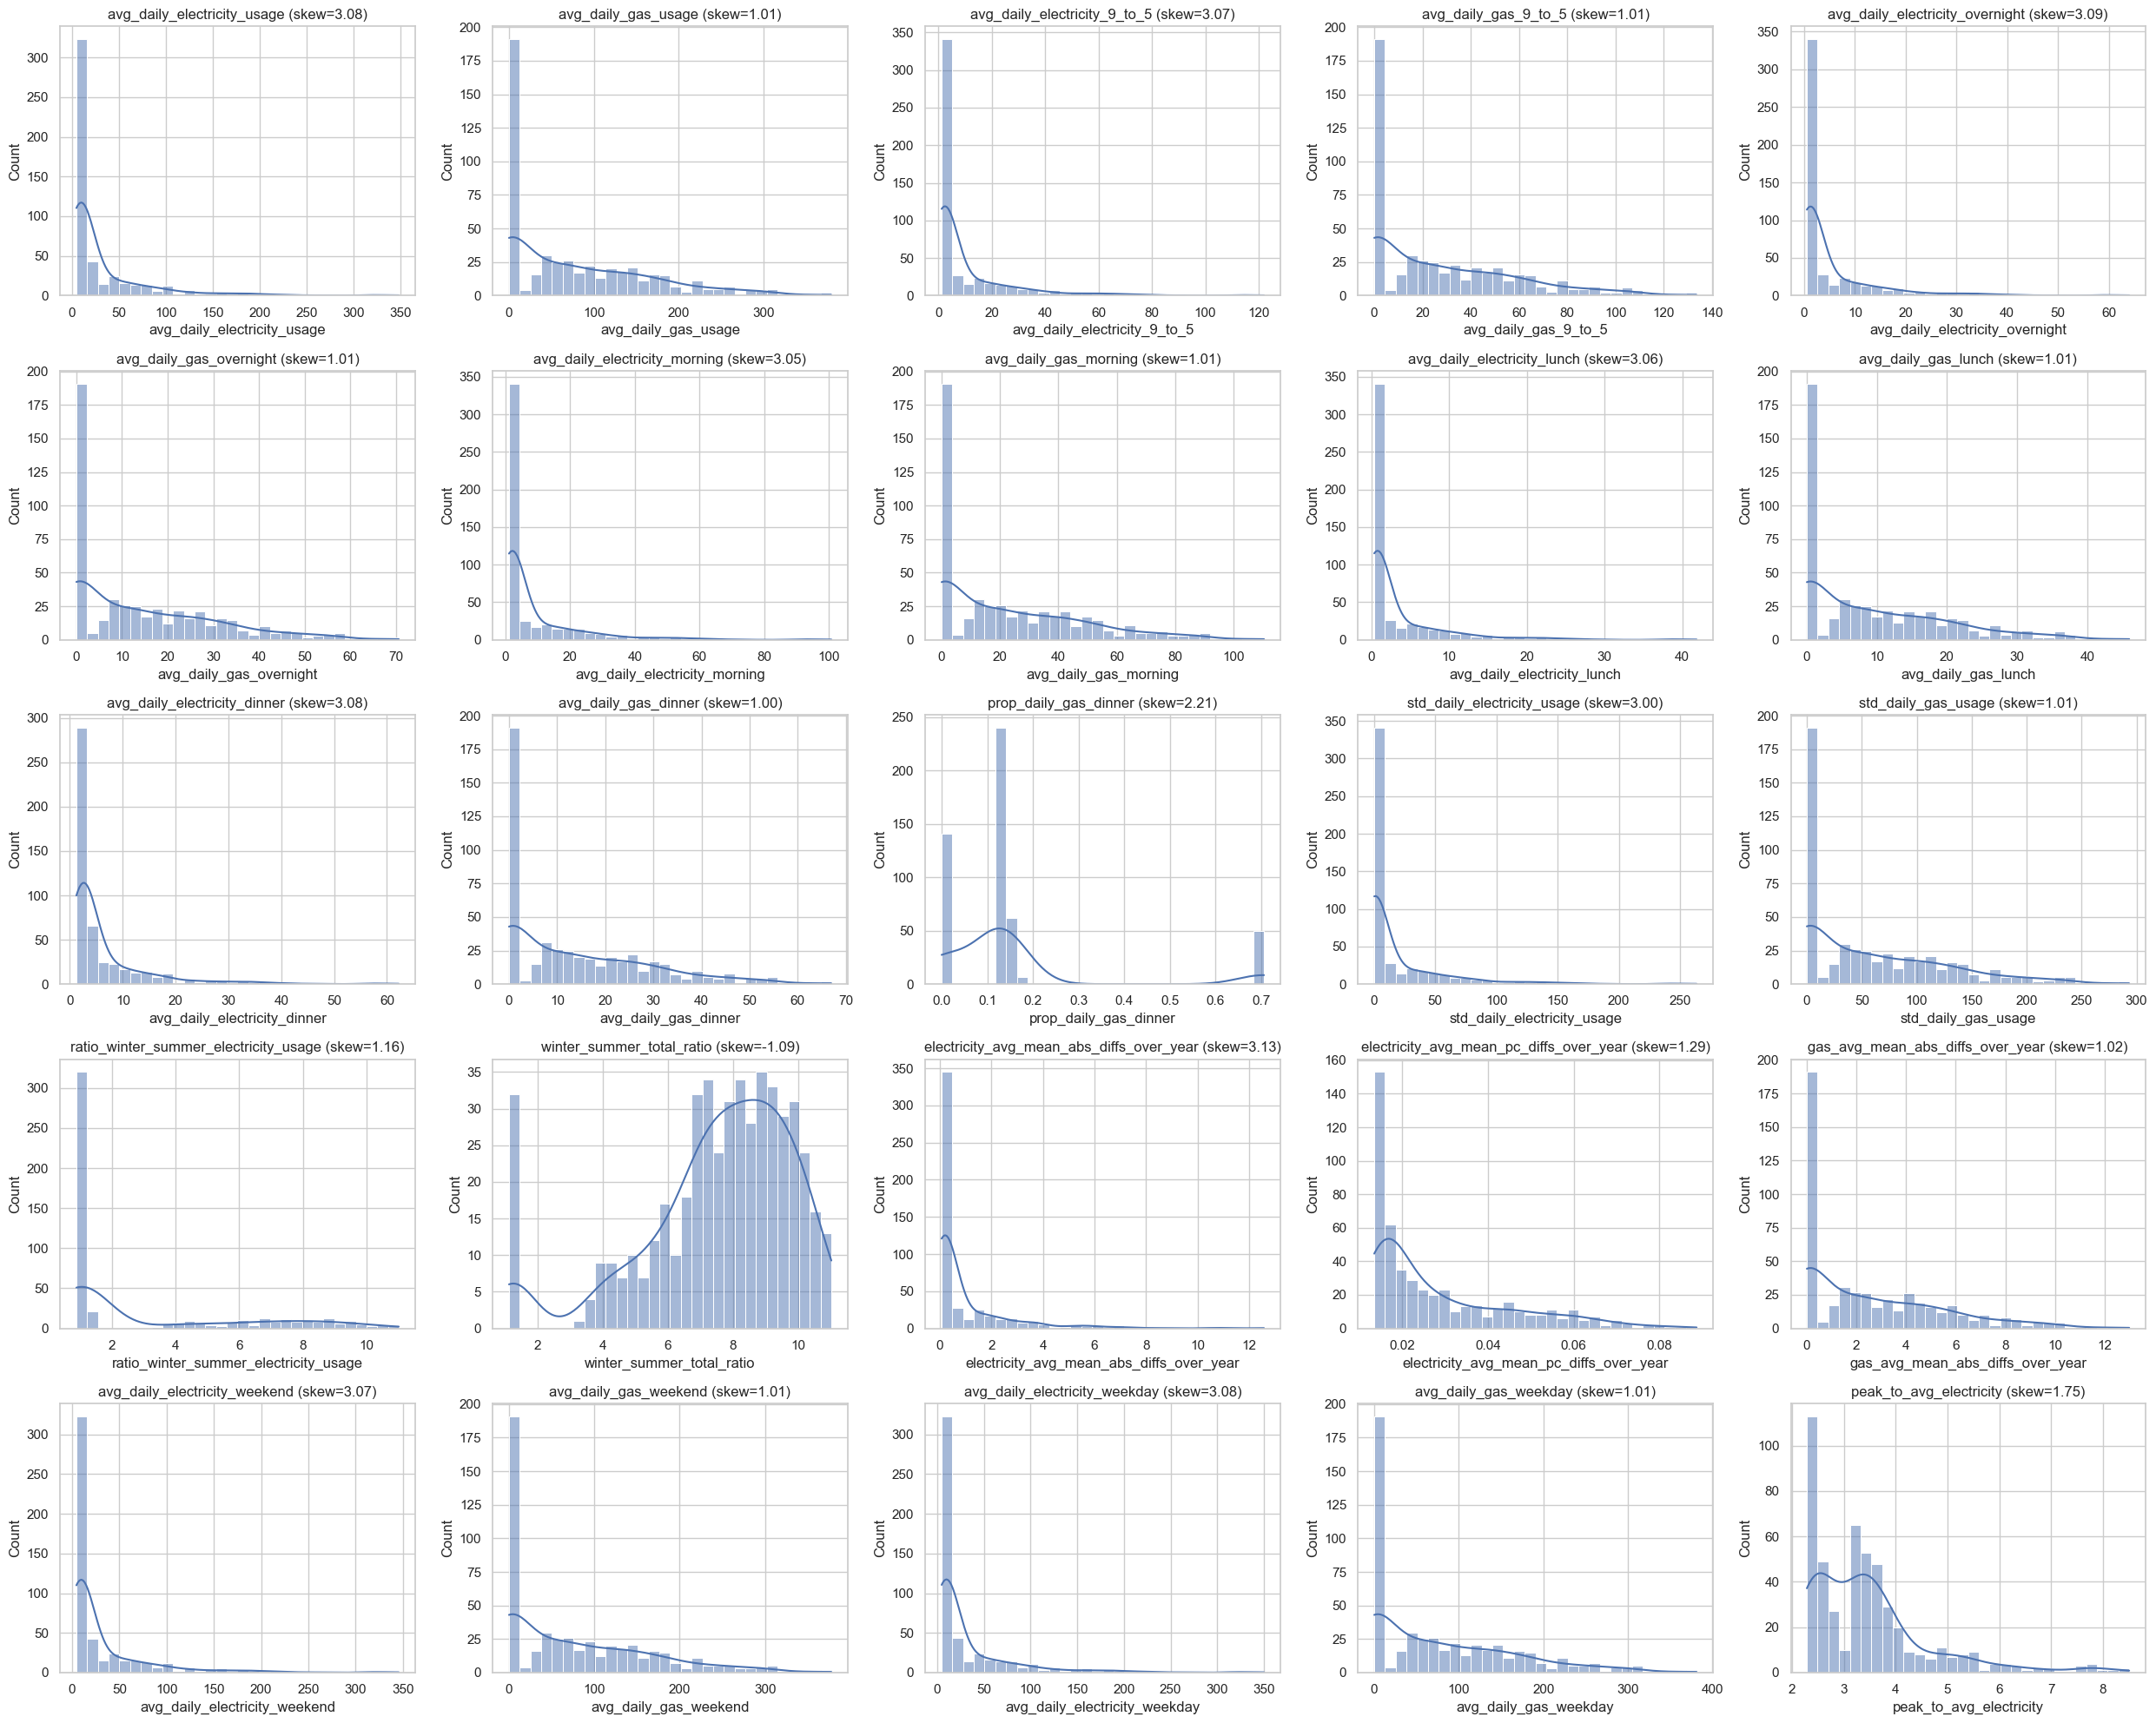

In [47]:
from scipy.stats import skew

# Calculate skewness for all features
features_for_clustering = features.copy().drop('household_id', axis=1)
skewness = features_for_clustering.skew()

# Display skewness sorted by magnitude
print("Skewness of features (sorted by magnitude):")
print(skewness.abs().sort_values(ascending=False))
print("\nHighly skewed features (|skewness| > 1):")
print(skewness[skewness.abs() > 1].sort_values(ascending=False))

# Visualization of most skewed features
skewed_features = skewness[skewness.abs() > 1].index
n_clo = 5
n_rows = (len(skewed_features) + n_clo - 1) // n_clo
plt.figure(figsize=(n_clo * 5, n_rows * 4))
for i, feature in enumerate(skewed_features):
    plt.subplot(n_rows, n_clo, i + 1)
    sns.histplot(features[feature], bins=30, kde=True)
    plt.title(f"{feature} (skew={skewness[feature]:.2f})")
plt.tight_layout()
plt.show()

### Choosing the best transformation per feature

For each feature with |skewness| > 1, we compare three candidate transformations:
- **log1p**: `log(1 + x)` — good for strongly right-skewed data with zeros
- **sqrt**: square root — milder than log, good for moderately skewed data
- **Box-Cox**: power transform with fitted λ — most flexible, finds optimal power

We exclude from transformation:
- **Proportions** (bounded [0,1]) — transforming would distort their natural scale
- **Binary flags** — categorical, not continuous
- **Already symmetric features** (|skew| ≤ 1) — no correction needed

In [48]:
from scipy.stats import boxcox
from scipy.stats import skew as scipy_skew

# Categorize features by type
proportion_cols = [c for c in features_for_clustering.columns if 'prop_' in c]
ratio_cols = [c for c in features_for_clustering.columns if 'ratio' in c or 'peak_to_avg' in c]
flag_cols = [c for c in features_for_clustering.columns if c in ['has_gas_usage']]
magnitude_cols = [c for c in features_for_clustering.columns 
                  if c not in proportion_cols + ratio_cols + flag_cols]

# Test transformations on all features with |skewness| > 1
candidates = skewness[skewness.abs() > 1].index.tolist()
# Exclude proportions (bounded [0,1]) and binary flags
candidates = [c for c in candidates if c not in proportion_cols + flag_cols]

results = []
for col in candidates:
    data = features_for_clustering[col].dropna()
    original_skew = scipy_skew(data)
    row = {"feature": col, "original_skew": original_skew, "type": "ratio" if col in ratio_cols else "magnitude"}
    
    # log1p (requires data >= 0)
    if data.min() >= 0:
        row["log1p_skew"] = scipy_skew(np.log1p(data))
    else:
        row["log1p_skew"] = np.nan
    
    # sqrt (requires data >= 0)
    if data.min() >= 0:
        row["sqrt_skew"] = scipy_skew(np.sqrt(data))
    else:
        row["sqrt_skew"] = np.nan
    
    # Box-Cox (requires data > 0 strictly)
    if data.min() > 0:
        try:
            transformed, lam = boxcox(data)
            row["boxcox_skew"] = scipy_skew(transformed)
            row["boxcox_lambda"] = lam
        except Exception:
            row["boxcox_skew"] = np.nan
            row["boxcox_lambda"] = np.nan
    else:
        row["boxcox_skew"] = np.nan
        row["boxcox_lambda"] = np.nan
    
    # Pick best transformation
    options = {
        "none": abs(original_skew),
        "log1p": abs(row.get("log1p_skew", np.nan)),
        "sqrt": abs(row.get("sqrt_skew", np.nan)),
        "boxcox": abs(row.get("boxcox_skew", np.nan)),
    }
    valid = {k: v for k, v in options.items() if not np.isnan(v)}
    row["best_transform"] = min(valid, key=valid.get)
    row["best_skew"] = valid[row["best_transform"]]
    
    results.append(row)

results_df = pd.DataFrame(results).set_index("feature")
results_df = results_df.sort_values("original_skew", key=abs, ascending=False)

# Display full comparison
pd.set_option("display.max_rows", 50)
pd.set_option("display.float_format", "{:.3f}".format)
print("=== TRANSFORMATION COMPARISON (|skew| > 1 features, excluding proportions & flags) ===\n")
print(results_df[["type", "original_skew", "log1p_skew", "sqrt_skew", "boxcox_skew", "boxcox_lambda", "best_transform", "best_skew"]].to_string())
print(len(results_df), "features analyzed, best transformations identified based on skewness reduction.")



=== TRANSFORMATION COMPARISON (|skew| > 1 features, excluding proportions & flags) ===

                                               type  original_skew  log1p_skew  sqrt_skew  boxcox_skew  boxcox_lambda best_transform  best_skew
feature                                                                                                                                        
electricity_avg_mean_abs_diffs_over_year  magnitude          3.120       1.590      1.723        0.294         -0.458         boxcox      0.294
avg_daily_electricity_overnight           magnitude          3.084       1.227      1.780        0.400         -0.624         boxcox      0.400
avg_daily_electricity_dinner              magnitude          3.071       1.238      1.870        0.262         -0.694         boxcox      0.262
avg_daily_electricity_weekday             magnitude          3.068       1.092      1.821        0.354         -0.680         boxcox      0.354
avg_daily_electricity_usage               magnit

## Step 2: Transform Skewed Features

Based on the comparison analysis above, we apply the **optimal transformation per feature**:

- **Box-Cox** (14 features): electricity magnitudes, variability, ratios — strongly right-skewed (skew 1–3+), Box-Cox with fitted λ gives best normalization
- **sqrt** (9 features): gas magnitudes — moderately skewed (~1.0), sqrt is sufficient
- **log1p** (1 feature): `gas_avg_mean_abs_diffs_over_year` — log1p is optimal here
- **No transform** (16 features): proportions (bounded [0,1]), binary flags, and already-symmetric features (|skew| ≤ 1)

In [49]:
from scipy.stats import boxcox

features_transformed = features.copy()

# Build transformation plan from the analysis results
boxcox_features = results_df[results_df["best_transform"] == "boxcox"].index.tolist()
sqrt_features = results_df[results_df["best_transform"] == "sqrt"].index.tolist()
log1p_features = results_df[results_df["best_transform"] == "log1p"].index.tolist()

# Store Box-Cox lambdas for potential inverse transform later
boxcox_lambdas = {}

print("Applying optimal transformations:\n")

# Box-Cox (fitted λ per feature, requires data > 0)
for col in boxcox_features:
    data = features_transformed[col]
    transformed, lam = boxcox(data)
    features_transformed[col] = transformed
    boxcox_lambdas[col] = lam
    new_skew = features_transformed[col].skew()
    print(f"  [boxcox λ={lam:+.2f}] {col:<50s} skew: {skewness[col]:+.2f} → {new_skew:+.3f}")

# sqrt
for col in sqrt_features:
    features_transformed[col] = np.sqrt(features_transformed[col])
    new_skew = features_transformed[col].skew()
    print(f"  [sqrt]        {col:<50s} skew: {skewness[col]:+.2f} → {new_skew:+.3f}")

# log1p
for col in log1p_features:
    features_transformed[col] = np.log1p(features_transformed[col])
    new_skew = features_transformed[col].skew()
    print(f"  [log1p]       {col:<50s} skew: {skewness[col]:+.2f} → {new_skew:+.3f}")

# Verify
print(f"NaN count: {features_transformed.isnull().sum().sum()}")

Applying optimal transformations:

  [boxcox λ=-0.46] electricity_avg_mean_abs_diffs_over_year           skew: +3.13 → +0.295
  [boxcox λ=-0.62] avg_daily_electricity_overnight                    skew: +3.09 → +0.401
  [boxcox λ=-0.69] avg_daily_electricity_dinner                       skew: +3.08 → +0.263
  [boxcox λ=-0.68] avg_daily_electricity_weekday                      skew: +3.08 → +0.355
  [boxcox λ=-0.68] avg_daily_electricity_usage                        skew: +3.08 → +0.354
  [boxcox λ=-0.68] avg_daily_electricity_weekend                      skew: +3.07 → +0.354
  [boxcox λ=-0.75] avg_daily_electricity_9_to_5                       skew: +3.07 → +0.485
  [boxcox λ=-0.73] avg_daily_electricity_lunch                        skew: +3.06 → +0.486
  [boxcox λ=-0.75] avg_daily_electricity_morning                      skew: +3.05 → +0.475
  [boxcox λ=-0.33] std_daily_electricity_usage                        skew: +3.00 → +0.461
  [boxcox λ=-1.20] peak_to_avg_electricity             

## Step 3: Standardization

Scale all features to have mean=0 and std=1. Essential for K-means clustering.


In [50]:
from sklearn.preprocessing import StandardScaler

# Extract features (excluding household_id)
features_for_scaling = features_transformed.copy().drop('household_id', axis=1)

# Initialize and fit scaler
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features_for_scaling)

# Convert to DataFrame for easier handling
features_scaled_df = pd.DataFrame(
    features_scaled,
    columns=features_for_scaling.columns,
    index=features_for_scaling.index
)

print(f"Features scaled: {features_scaled_df.shape}")


Features scaled: (500, 40)


## Step 4: Correlation & Multicollinearity Check


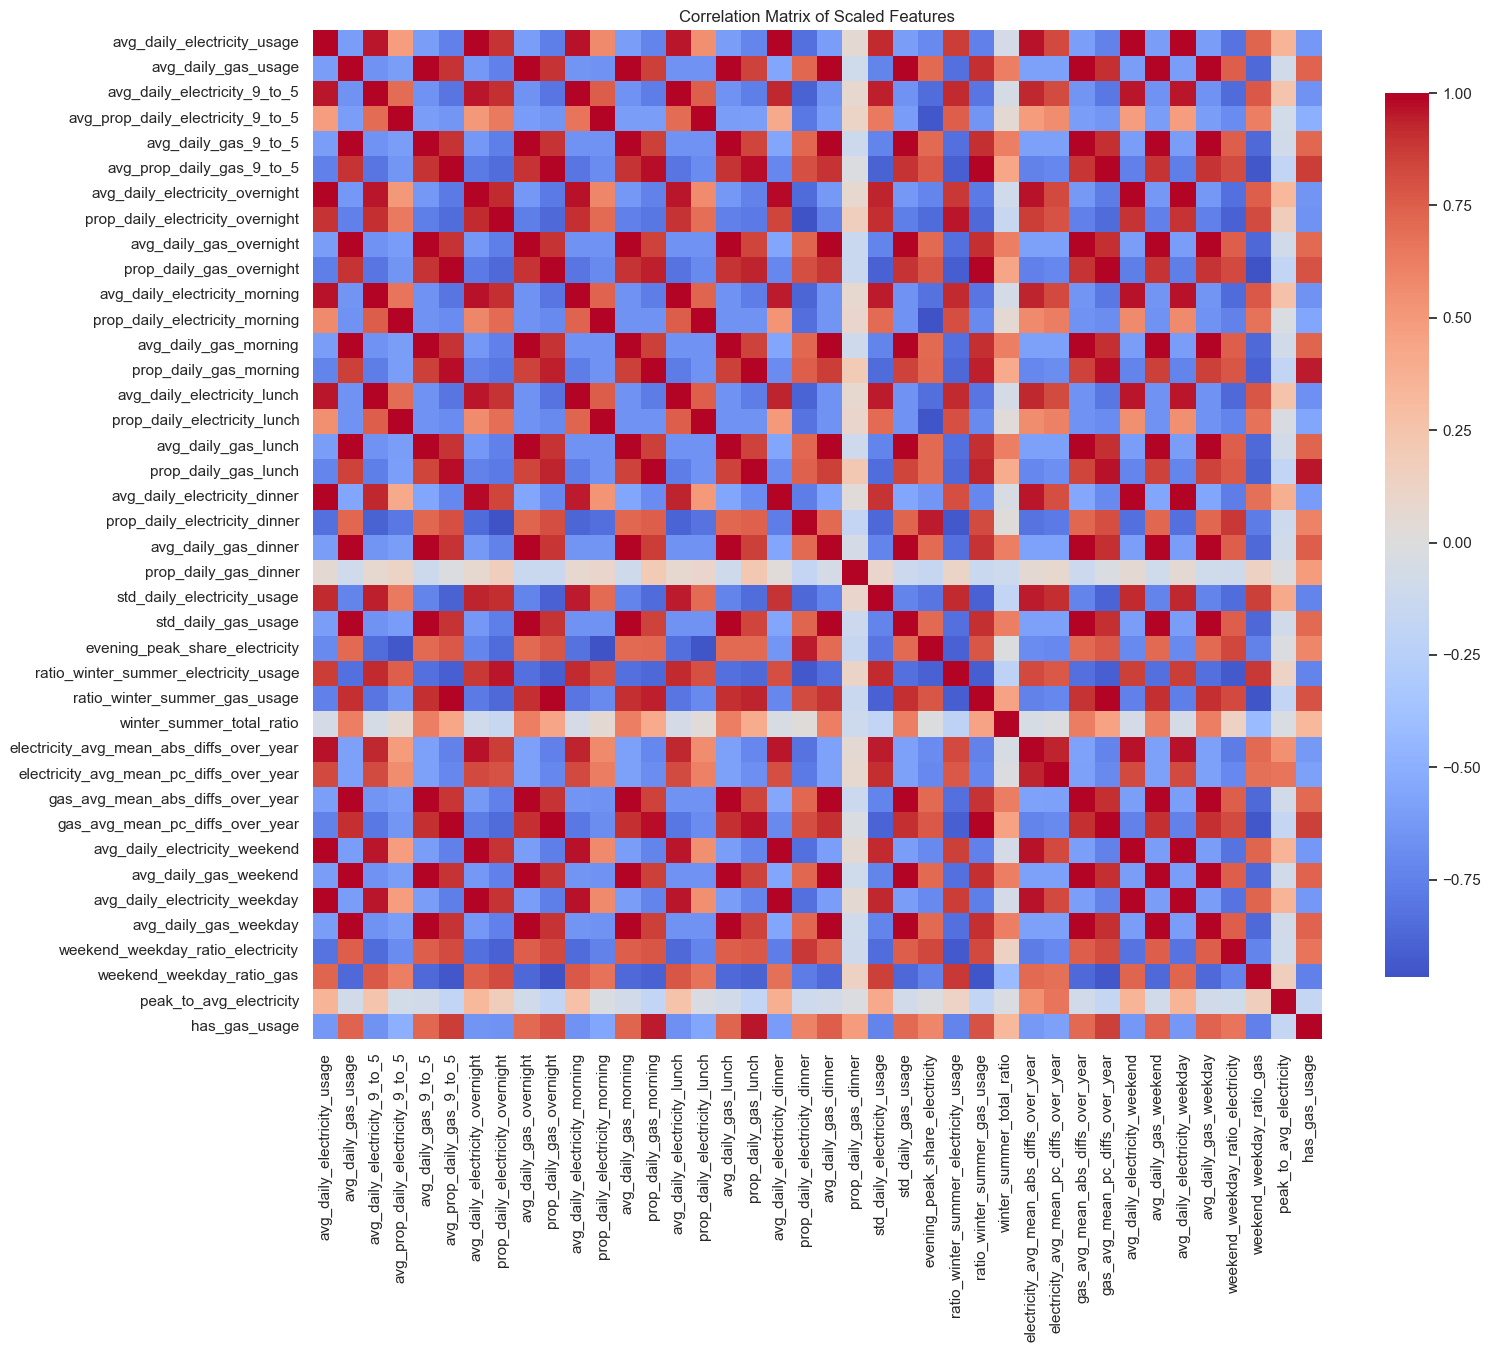

In [51]:
# Correlation heatmap
plt.figure(figsize=(16, 14))
correlation_matrix = features_scaled_df.corr()
sns.heatmap(correlation_matrix, cmap='coolwarm', center=0, square=True, 
            cbar_kws={"shrink": 0.8}, annot=False)
plt.title("Correlation Matrix of Scaled Features")
plt.tight_layout()
plt.show()

# Identify highly correlated feature pairs (|correlation| > 0.8)
# print("Highly correlated feature pairs (|correlation| > 0.8):")
# for i in range(len(correlation_matrix.columns)):
#     for j in range(i+1, len(correlation_matrix.columns)):
#         if abs(correlation_matrix.iloc[i, j]) > 0.8:
#             print(f"{correlation_matrix.columns[i]} <-> {correlation_matrix.columns[j]}: {correlation_matrix.iloc[i, j]:.3f}")


We can see many correlated pairs. But we are going to use PCA anyway, so we will let PCA deal with multicollinearity.

## Step 5: Principal Component Analysis (PCA)

Reduce dimensionality while retaining 95% of variance. Helps improve clustering efficiency and visualization.


Original number of features: 40
Number of PCA components (95% variance): 5
Cumulative variance explained: 0.9695


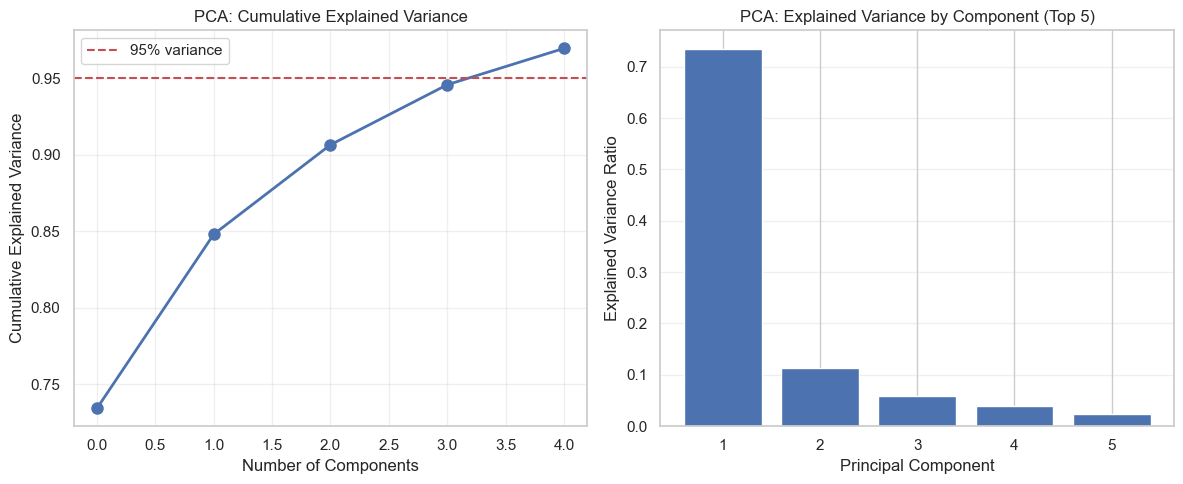


PCA features shape: (500, 5)

Explained variance by component:
  PC1: 0.7342 (0.7342 cumulative)
  PC2: 0.1137 (0.8479 cumulative)
  PC3: 0.0585 (0.9064 cumulative)
  PC4: 0.0393 (0.9457 cumulative)
  PC5: 0.0238 (0.9695 cumulative)

First 5 rows of PCA features:
     PC1    PC2    PC3    PC4    PC5
0 -3.629 -2.120  1.462  0.004 -0.302
1 -3.712  1.119 -0.673  0.107  1.150
2 -4.681  3.044  1.211 -0.690 -1.605
3  8.098  0.949 -0.216 -1.010  0.141
4  7.868  0.661 -0.116 -1.055  0.263


In [52]:
from sklearn.decomposition import PCA

# Apply PCA - retain 95% of variance (using cleaned features)
pca = PCA(n_components=0.95, random_state=42)
features_pca = pca.fit_transform(features_scaled_df)

print(f"Original number of features: {features_scaled_df.shape[1]}")
print(f"Number of PCA components (95% variance): {pca.n_components_}")
print(f"Cumulative variance explained: {pca.explained_variance_ratio_.sum():.4f}")

# Plot cumulative variance explained
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(np.cumsum(pca.explained_variance_ratio_), 'bo-', linewidth=2, markersize=8)
plt.axhline(y=0.95, color='r', linestyle='--', label='95% variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA: Cumulative Explained Variance')
plt.grid(True, alpha=0.3)
plt.legend()

plt.subplot(1, 2, 2)
n_components_to_plot = min(len(pca.explained_variance_ratio_), 20)
plt.bar(range(1, n_components_to_plot + 1), 
        pca.explained_variance_ratio_[:n_components_to_plot])
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title(f'PCA: Explained Variance by Component (Top {n_components_to_plot})')
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Create DataFrame with PCA features
features_pca_df = pd.DataFrame(
    features_pca,
    columns=[f'PC{i+1}' for i in range(features_pca.shape[1])],
    index=features_scaled_df.index
)

print(f"\nPCA features shape: {features_pca_df.shape}")
print(f"\nExplained variance by component:")
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f"  PC{i+1}: {var:.4f} ({np.cumsum(pca.explained_variance_ratio_)[i]:.4f} cumulative)")
print(f"\nFirst 5 rows of PCA features:")
print(features_pca_df.head())


## Summary

Preprocessing complete! You now have:
- **`features_scaled`**: Standardized features ready for clustering
- **`features_pca`**: PCA-reduced features (95% variance retained)

### Next Steps:
1. Use silhouette analysis to find optimal number of clusters
2. Apply K-means clustering
3. Profile and interpret the clusters
4. Link clusters back to household metadata for actionable insights


# 4. Clustering

An energy-use profile is a group of households that share similar patterns of energy consumption. In this section, we identify optimal clusters using silhouette analysis, apply K-means clustering, and profile the resulting segments before linking them back to household metadata.

## 4.1 Silhouette Analysis

We test K-Means for K = 2 to 10 and evaluate each using:
- **Silhouette score**: measures how similar a point is to its own cluster vs. neighbouring clusters (higher = better, range [-1, 1])
- **Inertia** (within-cluster sum of squares): measures compactness (lower = better, but always decreases with K — look for the "elbow")
- **Silhouette plots**: per-cluster breakdown to check for uneven or thin clusters

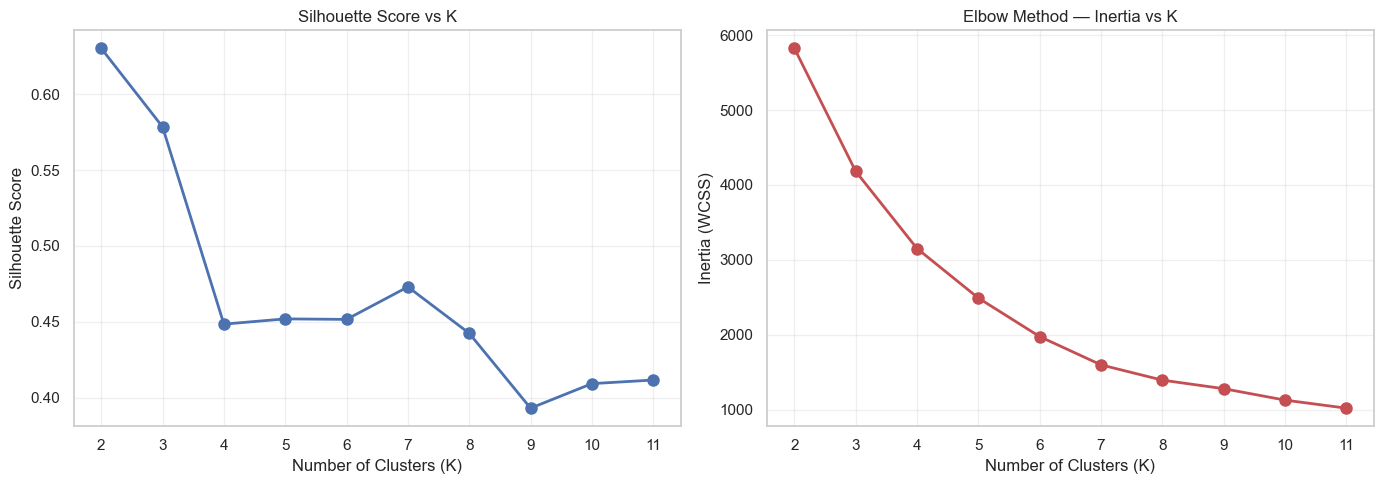

  K= 2  silhouette=0.6305  inertia=5825.7 <--
  K= 3  silhouette=0.5786  inertia=4181.9
  K= 4  silhouette=0.4484  inertia=3150.9
  K= 5  silhouette=0.4519  inertia=2489.6
  K= 6  silhouette=0.4516  inertia=1974.5
  K= 7  silhouette=0.4730  inertia=1596.8
  K= 8  silhouette=0.4424  inertia=1392.7
  K= 9  silhouette=0.3930  inertia=1278.8
  K=10  silhouette=0.4092  inertia=1126.0
  K=11  silhouette=0.4115  inertia=1018.3


In [53]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
import matplotlib.cm as cm

K_range = range(2, 12)
silhouette_scores = []
inertias = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = kmeans.fit_predict(features_pca_df)
    silhouette_scores.append(silhouette_score(features_pca_df, labels))
    inertias.append(kmeans.inertia_)

# Plot silhouette scores and inertia
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(K_range), silhouette_scores, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel("Number of Clusters (K)")
axes[0].set_ylabel("Silhouette Score")
axes[0].set_title("Silhouette Score vs K")
axes[0].set_xticks(list(K_range))
axes[0].grid(True, alpha=0.3)

axes[1].plot(list(K_range), inertias, 'ro-', linewidth=2, markersize=8)
axes[1].set_xlabel("Number of Clusters (K)")
axes[1].set_ylabel("Inertia (WCSS)")
axes[1].set_title("Elbow Method — Inertia vs K")
axes[1].set_xticks(list(K_range))
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print scores
for k, s, i in zip(K_range, silhouette_scores, inertias):
    marker = " <--" if s == max(silhouette_scores) else ""
    print(f"  K={k:2d}  silhouette={s:.4f}  inertia={i:.1f}{marker}")

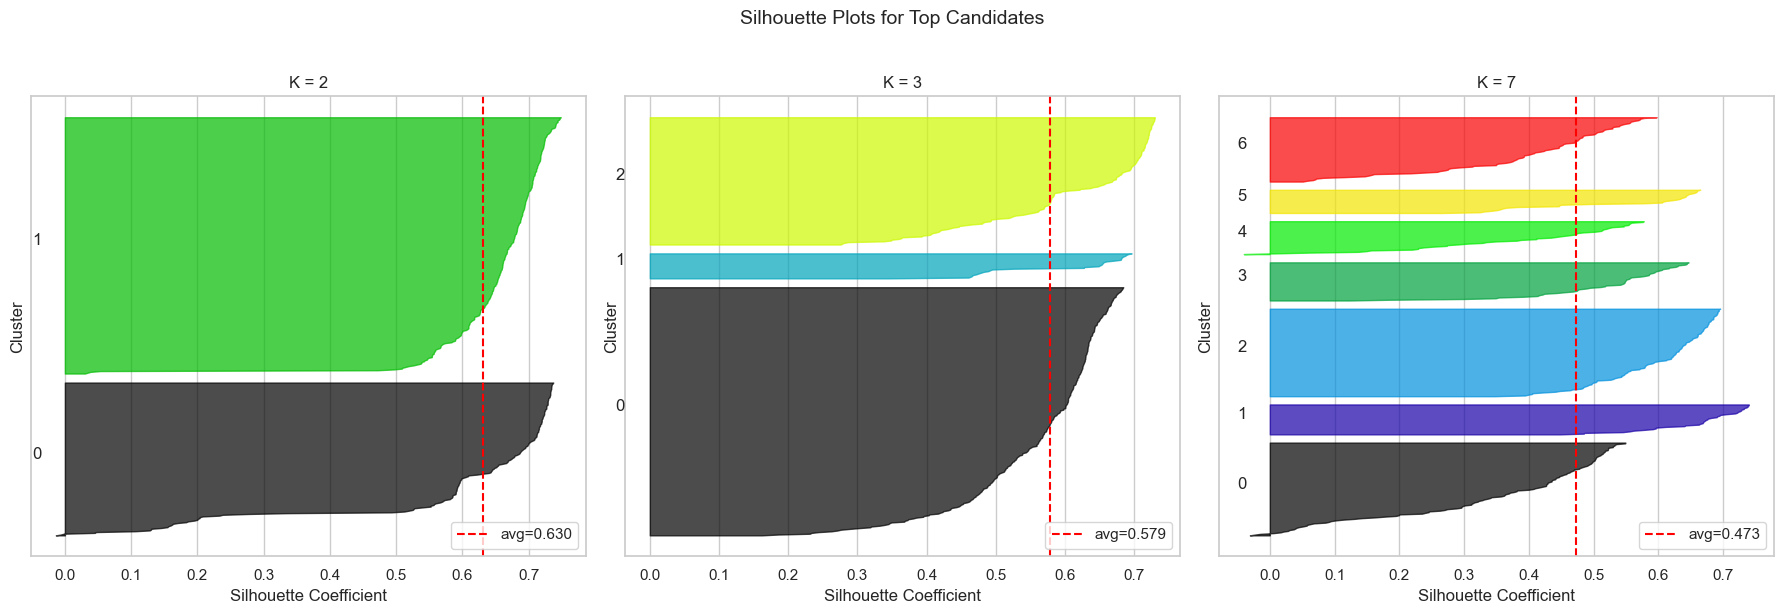

In [54]:
# Detailed silhouette plots for the top 3 candidates
top_3 = sorted(zip(K_range, silhouette_scores), key=lambda x: x[1], reverse=True)[:3]
top_ks = sorted([k for k, _ in top_3])

fig, axes = plt.subplots(1, len(top_ks), figsize=(6 * len(top_ks), 6))
if len(top_ks) == 1:
    axes = [axes]

for ax, k in zip(axes, top_ks):
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = kmeans.fit_predict(features_pca_df)
    sample_silhouette_values = silhouette_samples(features_pca_df, labels)
    avg_score = silhouette_score(features_pca_df, labels)
    
    y_lower = 10
    for i in range(k):
        cluster_values = sample_silhouette_values[labels == i]
        cluster_values.sort()
        
        size_cluster = cluster_values.shape[0]
        y_upper = y_lower + size_cluster
        
        color = cm.nipy_spectral(float(i) / k)
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_values,
                         facecolor=color, edgecolor=color, alpha=0.7)
        ax.text(-0.05, y_lower + 0.5 * size_cluster, str(i))
        y_lower = y_upper + 10
    
    ax.axvline(x=avg_score, color="red", linestyle="--", label=f"avg={avg_score:.3f}")
    ax.set_title(f"K = {k}")
    ax.set_xlabel("Silhouette Coefficient")
    ax.set_ylabel("Cluster")
    ax.legend(loc="lower right")
    ax.set_yticks([])

plt.suptitle("Silhouette Plots for Top Candidates", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Interpretation

| K | Silhouette | Inertia | Assessment |
|---|-----------|---------|------------|
| 2 | **0.630** (best) | ~5900 | Highest separation, but only 2 segments — too coarse for actionable profiling |
| 3 | 0.579 | ~4100 | Good separation with 3 distinct groups; cluster 1 is thin |
| 7 | 0.473 | ~1800 | Local peak in silhouette; finer granularity for richer behavioral segmentation |

**Elbow analysis:** The inertia curve shows a clear bend around K=4–5, after which gains diminish.

**Silhouette plots:**
- **K=2**: Both clusters are wide and clean, but a binary split (high/low consumers) lacks the granularity needed for targeted business strategies.
- **K=3**: Solid structure overall. Cluster 0 has a long tail of low-silhouette points, suggesting internal heterogeneity that could be split further.
- **K=7**: More fine-grained. Despite a lower average score, the per-cluster silhouettes show well-defined sub-groups. . No cluster has predominantly negative silhouette values, which means no segment is "artificial." Crucially, **all 7 clusters extend beyond the average silhouette dashed line**, confirming that every segment has a core of well-assigned households.

**Choice:** We select **K=7**. While K=2 and K=3 score higher statistically, K=7 offers the granularity required for meaningful energy-use profiling.  The silhouette score of 0.47 remains well above the threshold for reasonable structure (>0.25), and importantly, K=7 is a **local peak** — K=6 and K=8 both score lower — indicating a natural structure in the data at this resolution. More clusters also means richer input for the multi-agent LLM architecture to generate distinct, interpretable segment names.

## 4.2 K-Means Clustering

Fit K-Means with K=7 as justified by the silhouette analysis above.

In [55]:
features_pca_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   PC1     500 non-null    float64
 1   PC2     500 non-null    float64
 2   PC3     500 non-null    float64
 3   PC4     500 non-null    float64
 4   PC5     500 non-null    float64
dtypes: float64(5)
memory usage: 19.7 KB


Selected K: 7

Cluster distribution:


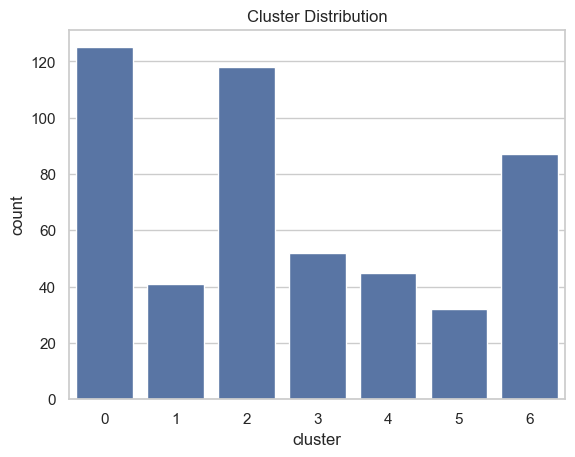

cluster
0    125
1     41
2    118
3     52
4     45
5     32
6     87
Name: count, dtype: int64

Silhouette score: 0.4730


In [56]:
# Select K=7 — local silhouette peak with granularity for meaningful profiling
optimal_k = 7
print(f"Selected K: {optimal_k}")

# Fit final K-Means
pca_cols = [col for col in features_pca_df.columns if col.startswith("PC")]
kmeans_final = KMeans(n_clusters=optimal_k, n_init=20, random_state=42)
cluster_labels = kmeans_final.fit_predict(features_pca_df[pca_cols])

# Attach labels to dataframes
features["cluster"] = cluster_labels
features_pca_df["cluster"] = cluster_labels
features_scaled_df["cluster"] = cluster_labels

print(f"\nCluster distribution:")
# visualize cluster distribution

import matplotlib.pyplot as plt

sns.countplot(x="cluster", data=features)
plt.title("Cluster Distribution")
plt.show()

print(features["cluster"].value_counts().sort_index())


print(f"\nSilhouette score: {silhouette_score(features_pca_df[pca_cols], cluster_labels):.4f}")

## 4.3 Cluster Visualization in PCA Space

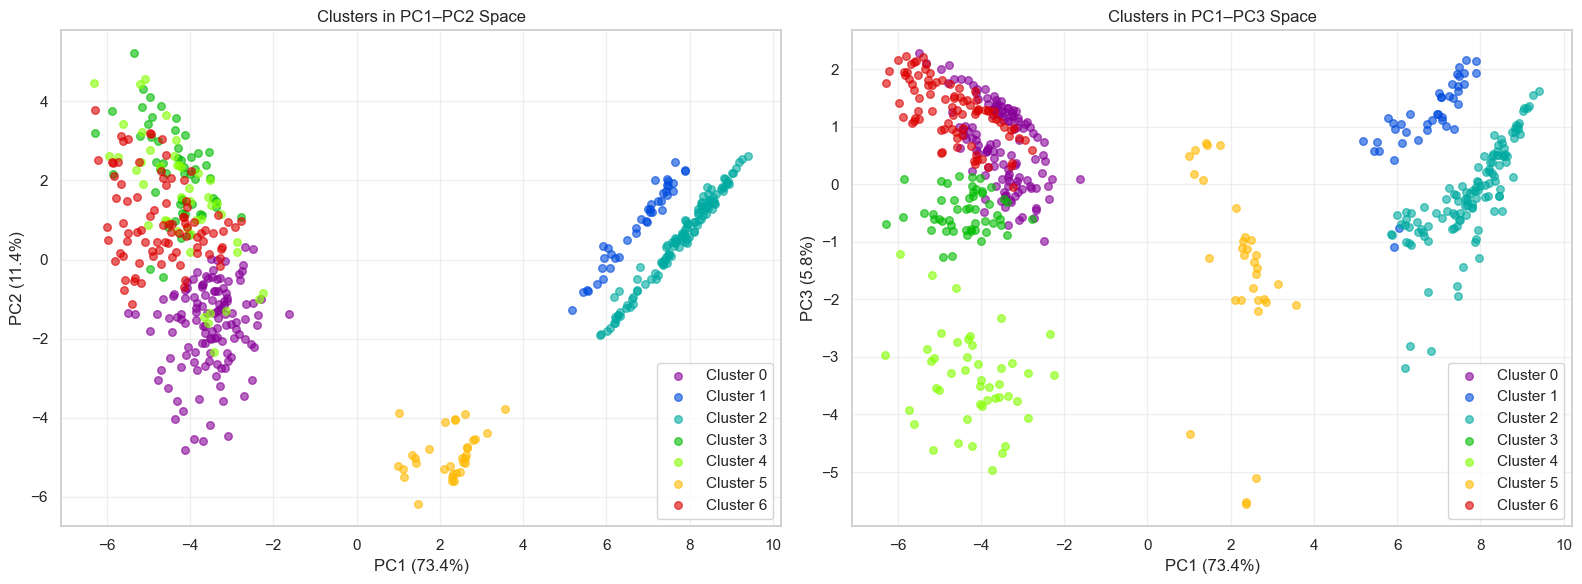

In [57]:
# 2D scatter: PC1 vs PC2
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

scatter_data = features_pca_df.copy()
colors = cm.nipy_spectral(np.linspace(0.1, 0.9, optimal_k))

# PC1 vs PC2
for c in range(optimal_k):
    mask = scatter_data["cluster"] == c
    axes[0].scatter(scatter_data.loc[mask, "PC1"], scatter_data.loc[mask, "PC2"],
                    c=[colors[c]], label=f"Cluster {c}", alpha=0.6, s=30)
axes[0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
axes[0].set_title("Clusters in PC1–PC2 Space")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# PC1 vs PC3
for c in range(optimal_k):
    mask = scatter_data["cluster"] == c
    axes[1].scatter(scatter_data.loc[mask, "PC1"], scatter_data.loc[mask, "PC3"],
                    c=[colors[c]], label=f"Cluster {c}", alpha=0.6, s=30)
axes[1].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
axes[1].set_ylabel(f"PC3 ({pca.explained_variance_ratio_[2]:.1%})")
axes[1].set_title("Clusters in PC1–PC3 Space")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [58]:
# Interactive 3D PCA scatter
import plotly.express as px

plot_df = features_pca_df[["PC1", "PC2", "PC3", "cluster"]].copy()
plot_df["cluster"] = plot_df["cluster"].astype(str)

fig = px.scatter_3d(
    plot_df, x="PC1", y="PC2", z="PC3",
    color="cluster",
    title="3D PCA — Cluster Visualization",
    opacity=0.7,
    labels={
        "PC1": f"PC1 ({pca.explained_variance_ratio_[0]:.1%})",
        "PC2": f"PC2 ({pca.explained_variance_ratio_[1]:.1%})",
        "PC3": f"PC3 ({pca.explained_variance_ratio_[2]:.1%})",
    }
)
fig.update_layout(width=900, height=700)
fig.show()

### Interpretation of Cluster Visualization

**Cluster distribution:** The 7 clusters range from 33 to 125 households. Clusters 0 and 2 are the largest (~125 and ~118), while cluster 5 is the smallest (~33). No cluster is trivially small, which confirms that K=7 does not over-segment.

**PC1–PC2 space (73.4% + 11.4% = 84.8% variance):**
- **PC1 is the dominant axis** and clearly separates households by overall consumption volume. Low-consumption clusters (0, 3, 4, 6) sit on the left (PC1 < 0), while high-consumption clusters (1, 2) are on the right (PC1 > 0). Cluster 5 occupies an intermediate position.
- **PC2 differentiates behavioral patterns** within similar consumption levels. On the left (low-consumption) side, clusters 3 and 4 (green/yellow-green) scatter upward, while cluster 0 (purple) clusters lower, suggesting different usage shapes despite similar volumes.
- **Cluster 2 ** forms a tight, elongated cloud at the high end of PC1 , these are likely the highest consumers with consistent patterns.
- **Cluster 5 (orange)** is isolated in a distinct region (moderate PC1, strongly negative PC2), suggesting a unique behavioral profile different from both low and high consumers.

**PC1–PC3 space (73.4% + 5.8%):**
- PC3 provides further separation, especially among the left-side clusters. Cluster 3 (green) drops to very negative PC3 values, clearly distinguishing it from clusters 0, 4, and 6 which overlap more in PC1–PC2.
- On the right side, clusters 1 (blue) and 2 (cyan) remain well-separated along PC3.
<>
**Key takeaway:** The 7 clusters are spatially well-defined in PCA space. The primary separation is along PC1 (consumption volume), while PC2 and PC3 reveal behavioral sub-groups within volume tiers. Some overlap exists among the low-consumption clusters in 2D — the 3D view (above) confirms they occupy distinct regions when all three components are considered.

## 4.4 Cluster Profiling

Analyze the **original (untransformed) features** per cluster to understand what differentiates each segment in interpretable terms.

In [59]:
# Cluster means on original features (untransformed, interpretable)
cluster_profile = features.drop(columns="household_id").groupby("cluster").mean()

# Transpose for readability: features as rows, clusters as columns
profile_T = cluster_profile.T
profile_T.columns = [f"Cluster {c}" for c in profile_T.columns]
profile_T["overall_mean"] = features.drop(columns=["household_id", "cluster"]).mean()

pd.set_option("display.float_format", "{:.3f}".format)
print(f"Cluster profile — mean of original features (K={optimal_k}):\n")
profile_T

Cluster profile — mean of original features (K=7):



,Cluster 0,Cluster 1,Cluster 2,Cluster 3,Cluster 4,Cluster 5,Cluster 6,overall_mean
avg_daily_electricity_usage,6.948,62.604,85.390,8.960,14.710,8.479,8.400,31.283
avg_daily_gas_usage,61.370,0.543,0.000,186.520,145.304,0.148,171.961,77.793
avg_daily_electricity_9_to_5,1.880,21.568,29.181,2.362,2.174,2.097,2.295,10.100
avg_prop_daily_electricity_9_to_5,0.271,0.348,0.341,0.265,0.149,0.259,0.273,0.282
avg_daily_gas_9_to_5,21.557,0.044,0.000,65.694,51.142,0.012,60.542,27.363
avg_prop_daily_gas_9_to_5,0.398,0.081,0.000,0.405,0.401,0.023,0.404,0.256
avg_daily_electricity_overnight,0.838,11.150,15.231,1.054,1.903,1.079,1.024,5.247
prop_daily_electricity_overnight,0.121,0.161,0.158,0.118,0.129,0.126,0.122,0.134
avg_daily_gas_overnight,11.342,0.000,0.000,34.594,26.930,0.000,31.888,14.406
prop_daily_gas_overnight,0.160,0.000,0.000,0.162,0.161,0.000,0.162,0.100


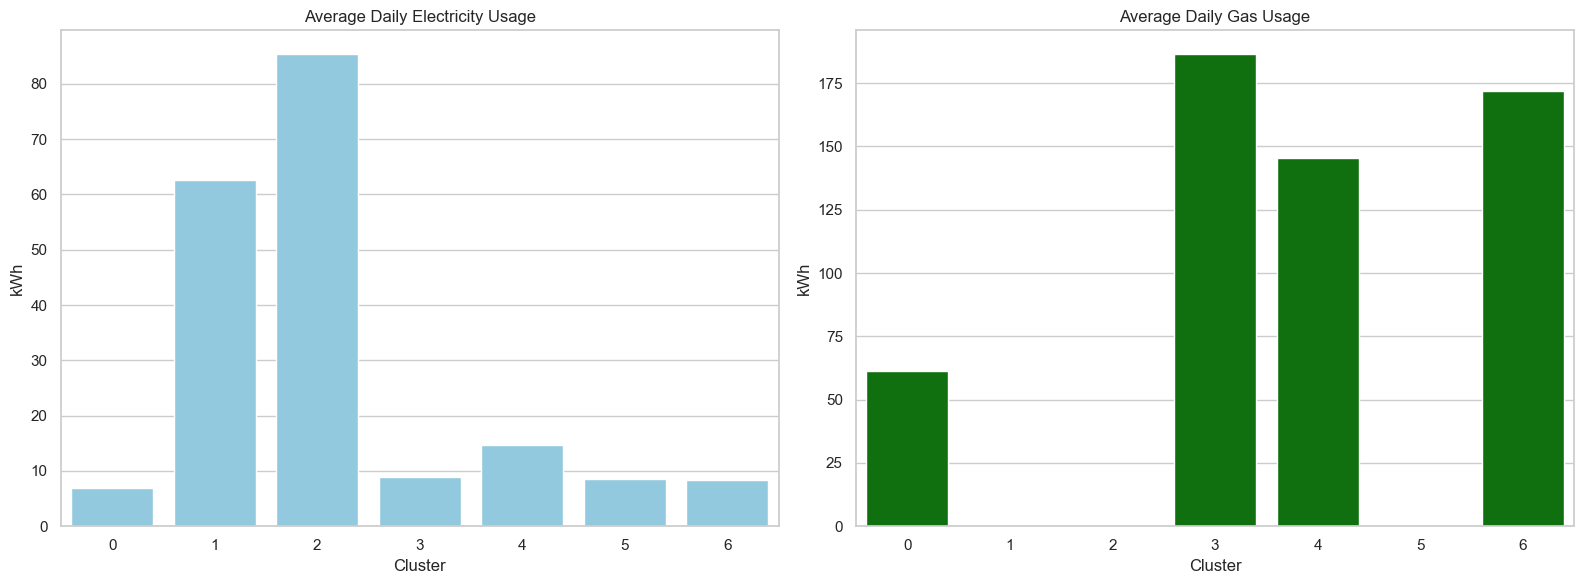

In [60]:
# Plot average daily energy consumption for each energy-use profile (2 plots: electricity and gas)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
# Electricity
sns.barplot(x=cluster_profile.index, y=cluster_profile["avg_daily_electricity_usage"], ax=axes[0],color='skyblue' )
axes[0].set_title("Average Daily Electricity Usage")
axes[0].set_xlabel("Cluster")
axes[0].set_ylabel("kWh")

# Gas
sns.barplot(x=cluster_profile.index, y=cluster_profile["avg_daily_gas_usage"], ax=axes[1],color='green')
axes[1].set_title("Average Daily Gas Usage")
axes[1].set_xlabel("Cluster")
axes[1].set_ylabel("kWh")

plt.tight_layout()
plt.show()

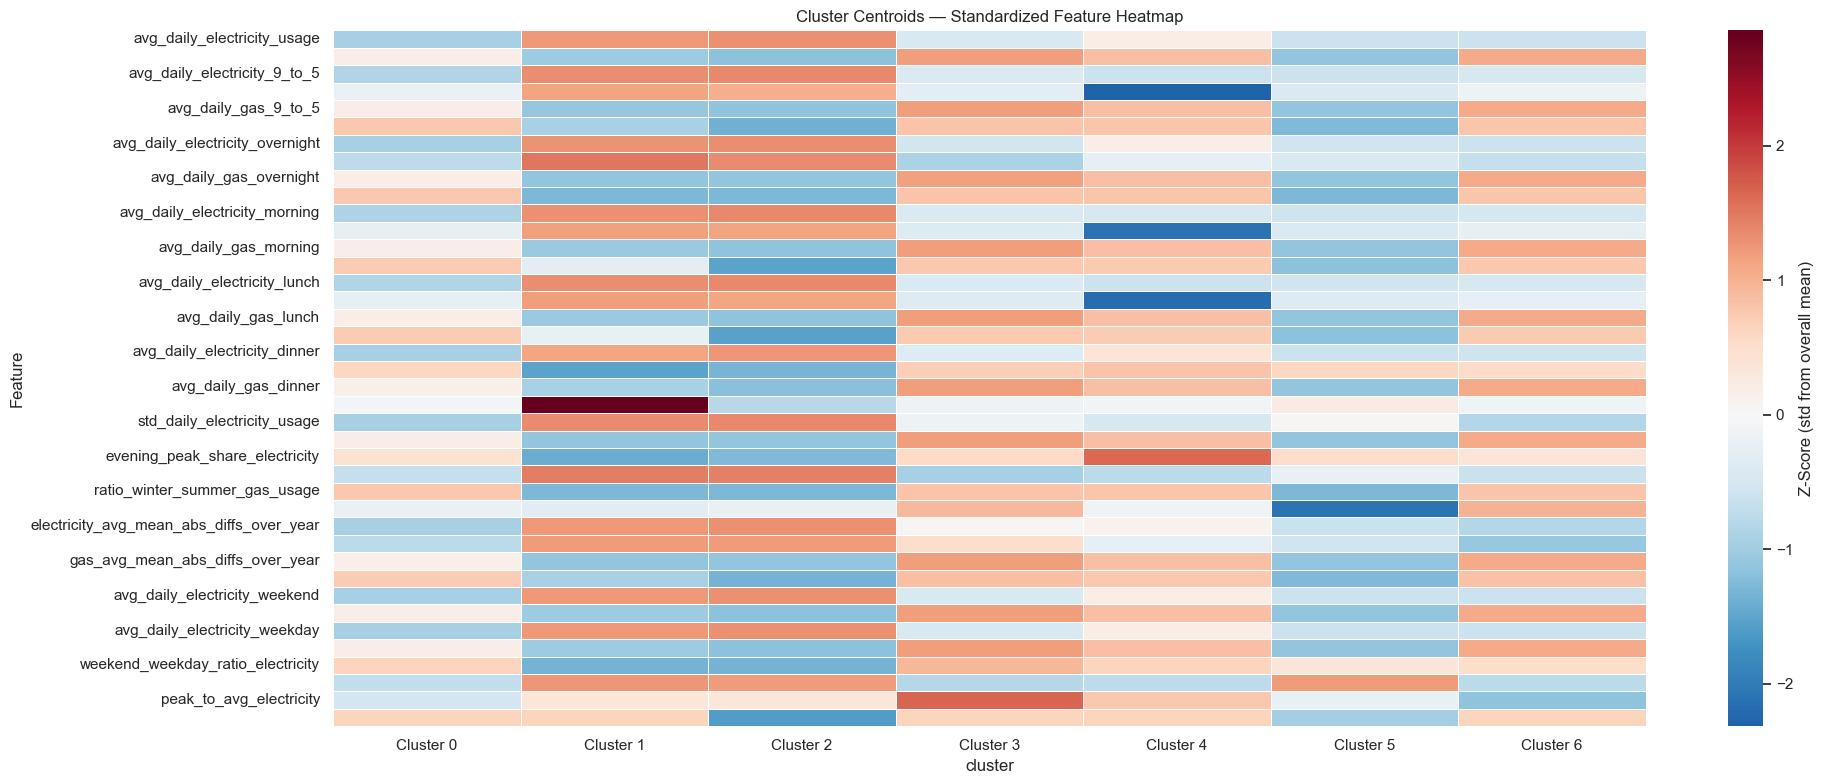

In [61]:
# Heatmap of standardized cluster centroids (z-score per feature)
cluster_profile_scaled = features_scaled_df.groupby("cluster").mean()

plt.figure(figsize=(20, 8))
sns.heatmap(cluster_profile_scaled.T, cmap="RdBu_r", center=0,
            xticklabels=[f"Cluster {c}" for c in cluster_profile_scaled.index],
            linewidths=0.5, cbar_kws={"label": "Z-Score (std from overall mean)"})
plt.title("Cluster Centroids — Standardized Feature Heatmap")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

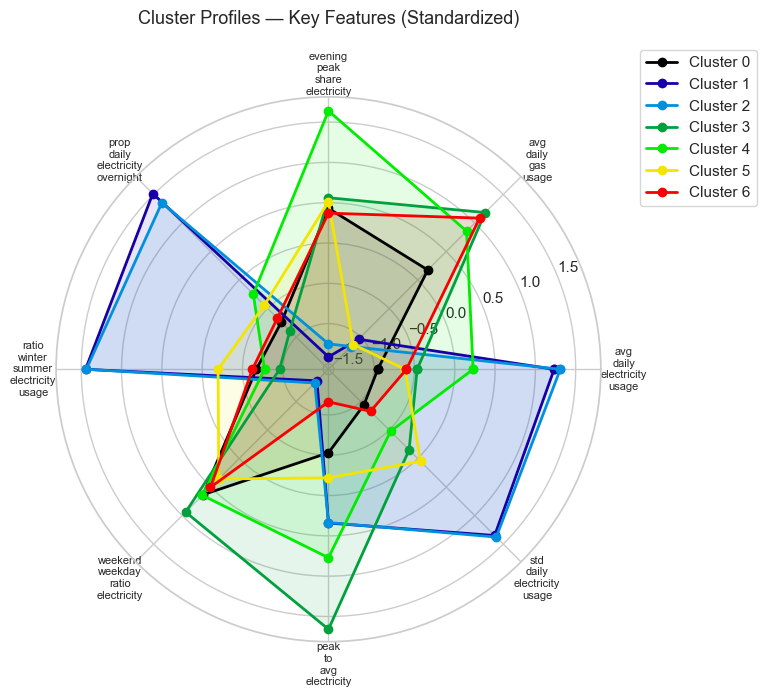

In [62]:
#

# Radar chart — key discriminating features per cluster
key_features = [
    "avg_daily_electricity_usage",
    "avg_daily_gas_usage",
    "evening_peak_share_electricity",
    "prop_daily_electricity_overnight",
    "ratio_winter_summer_electricity_usage",
    "weekend_weekday_ratio_electricity",
    "peak_to_avg_electricity",
    "std_daily_electricity_usage",
]

radar_data = cluster_profile_scaled[key_features]
angles = np.linspace(0, 2 * np.pi, len(key_features), endpoint=False).tolist()
angles += angles[:1]  # close the polygon

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
for c in radar_data.index:
    values = radar_data.loc[c].tolist()
    values += values[:1]
    color = cm.nipy_spectral(float(c) / optimal_k)
    ax.plot(angles, values, 'o-', linewidth=2, label=f"Cluster {c}", color=color)
    ax.fill(angles, values, alpha=0.1, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels([f.replace("_", "\n") for f in key_features], size=8)
ax.set_title("Cluster Profiles — Key Features (Standardized)", size=13, pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()

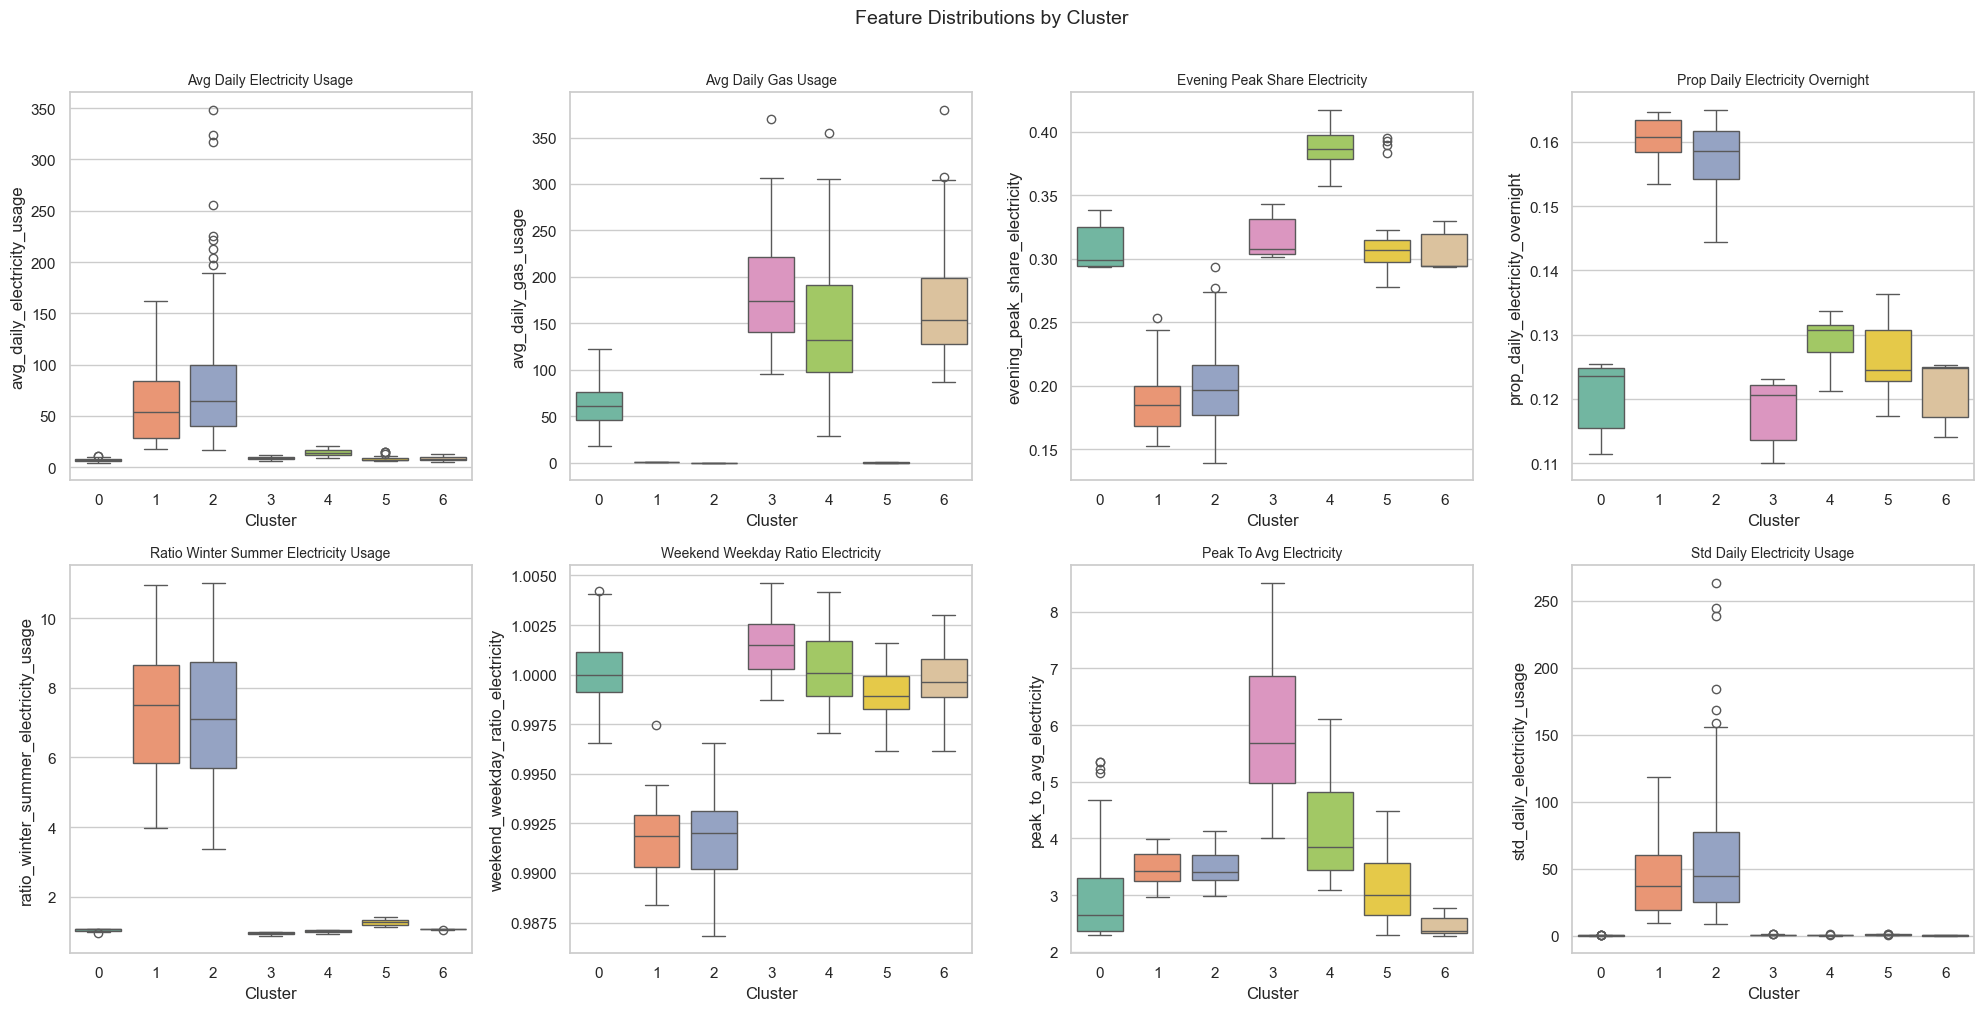

In [63]:
# Box plots — distribution of key features across clusters
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, feat in enumerate(key_features):
    sns.boxplot(x="cluster", y=feat, data=features, ax=axes[i], palette="Set2")
    axes[i].set_title(feat.replace("_", " ").title(), fontsize=10)
    axes[i].set_xlabel("Cluster")

plt.suptitle("Feature Distributions by Cluster", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

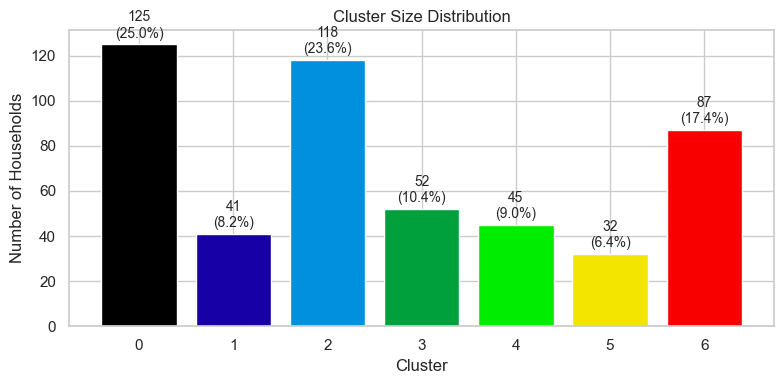

In [64]:
# Cluster sizes
cluster_counts = features["cluster"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(cluster_counts.index, cluster_counts.values, color=[cm.nipy_spectral(float(c) / optimal_k) for c in cluster_counts.index])
for bar, count in zip(bars, cluster_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 3,
            f"{count}\n({count/len(features)*100:.1f}%)", ha="center", fontsize=10)
ax.set_xlabel("Cluster")
ax.set_ylabel("Number of Households")
ax.set_title("Cluster Size Distribution")
ax.set_xticks(cluster_counts.index)
plt.tight_layout()
plt.show()

### Cluster Profiling — Interpretation

The profiling visualizations reveal **three macro-groups** defined primarily by energy source, and finer distinctions driven by consumption magnitude, time-of-day patterns, and variability.

---

#### Energy-source split

| Group | Clusters | Distinguishing trait |
|-------|----------|---------------------|
| **Gas-heated** | 0, 3, 4, 6 | Gas 61–187 kWh/day, winter/summer gas ratio ≈ 12× |
| **All-electric** | 1, 2 | Gas ≈ 0, electricity 63–85 kWh/day, winter/summer electricity ratio ≈ 7× |
| **Low-energy no-gas** | 5 | Gas ≈ 0, electricity ≈ 8.5 kWh/day — minimal consumption |

---

#### Per-cluster profiles

| Cluster | Size | Electricity (kWh/day) | Gas (kWh/day) | Key behavioural traits |
|---------|------|----------------------|---------------|------------------------|
| **0 — Low-Electricity Gas-Heated** | 125 (25.0%) | 6.9 | 61.4 | Lowest electricity. Moderate, seasonal gas (12× winter/summer). Very stable day-to-day electricity (std ≈ 0.2). Flat intra-day profile. Likely small or energy-efficient gas-heated homes. |
| **1 — Moderate All-Electric** | 41 (8.2%) | 62.6 | 0.5 | Zero gas. High overnight electricity proportion (18% of daily use). Winter electricity 7× summer → electric heating. High variability (std ≈ 44.5). Possibly homes with storage heaters or overnight EV charging. |
| **2 — Heavy All-Electric** | 118 (23.6%) | 85.4 | 0.0 | Zero gas. Highest electricity in the dataset. Highest variability (std ≈ 60.9) and peak-to-avg (3.5). Same seasonal pattern as Cluster 1 but 36% higher consumption — larger all-electric homes or those with heat pumps and EVs. |
| **3 — Gas-Dominant Evening Peakers** | 52 (10.4%) | 9.0 | 186.5 | Highest gas consumption. Highest peak-to-avg electricity (6.0) — very spiky electricity use. Highest evening peak share (~38%). Households that concentrate limited electricity use in the evening while relying almost entirely on gas. |
| **4 — Gas-Heavy Moderate Electricity** | 45 (9.0%) | 14.7 | 145.3 | Elevated electricity (double that of Clusters 0/6) alongside high gas. Elevated evening peak share. Moderate peak-to-avg (4.1). These households use notable electricity on top of a gas backbone — possibly dual-fuel cooking or supplementary electric heating. |
| **5 — Minimal-Usage No-Gas** | 32 (6.4%) | 8.5 | 0.1 | Smallest cluster. Near-zero gas, low electricity, minimal variability. Slight winter/summer electricity increase (1.3×). Possibly small apartments, holiday homes, or unoccupied properties — or homes with district heating (no gas or electric heating signature). |
| **6 — Gas-Dominant Steady** | 87 (17.4%) | 8.4 | 172.0 | Very high gas (close to Cluster 3) but with the lowest peak-to-avg electricity (2.4) — the flattest, most stable intra-day electricity profile. A "set-and-forget" gas-reliant consumption pattern with minimal electricity peaks. |

---

#### Key takeaways from the heatmap, radar chart, and box plots

- **Heatmap**: the dominant colour split is between gas-period features (bright red for Clusters 3/4/6, deep blue for Clusters 1/2) and electricity-magnitude/variability features (bright red for Clusters 1/2, deep blue for others). Cluster 0 is consistently near-zero (pale) on all standardized features — the baseline.
- **Radar chart**: Cluster 2 (blue) spans the widest on `avg_daily_electricity_usage`, `std_daily_electricity_usage`, and `peak_to_avg_electricity`. Cluster 3 (green) extends furthest on `evening_peak_share_electricity` and `avg_daily_gas_usage`. Cluster 1 (dark blue) leads on `prop_daily_electricity_overnight` and `ratio_winter_summer_electricity_usage`.
- **Box plots**: within-cluster spread is tight for Clusters 0, 5, 6 (homogeneous segments) and wide for Clusters 1, 2, 3 (more internal diversity), which is consistent with the silhouette plot observations.
- **Cluster sizes**: two dominant segments — Cluster 0 (25%) and Cluster 2 (24%) — together account for nearly half the population, while Cluster 5 (6.4%) is a niche micro-segment.

## 4.5 Summary

K-Means with K = 7 (silhouette score = 0.473) segments the 500 households into **three macro-groups**:

| Macro-group | Clusters | Households | Defining characteristic |
|-------------|----------|------------|------------------------|
| Gas-heated | 0, 3, 4, 6 | 309 (61.8%) | Rely on gas for heating (winter/summer gas ≈ 12×) |
| All-electric | 1, 2 | 159 (31.8%) | Zero gas; electric heating drives high seasonal electricity (7×) |
| Low-energy no-gas | 5 | 32 (6.4%) | Minimal consumption on both fuels |

Within these groups, clusters are further differentiated by **consumption magnitude** (Cluster 2 vs 1), **time-of-day profile** (Cluster 3's evening peaks vs 6's flat profile), and **day-to-day variability** (Clusters 1/2 are highly variable; 0/5/6 are stable).

### Next Steps
1. **Segment naming & interpretation**: use the multi-agent LLM architecture to generate stable, interpretable segment names from the cluster profiles
2. **Metadata enrichment**: join household metadata (dwelling type, occupancy) to validate cluster identities
3. **Tariff / demand-response design**: map each segment to tailored energy propositions (e.g., time-of-use tariffs for Clusters 1/2, gas-efficiency programmes for 3/6)

# 5. Agent-Based Segment Naming & Interpretation

---

The clustering pipeline (Sections 1–4) identified 7 statistically valid segments using **energy consumption features only**. This final section leverages a **role-specialized multi-agent LLM architecture** to:

1. **Name** each segment — three independent agents (Energy Domain Expert, Behavioral Analyst, Data Storyteller) propose names; a Judge agent synthesizes the final label.
2. **Interpret** each segment deeply — an Interpretation agent receives the energy profile **plus household metadata** to produce a rich, contextualised narrative.

This two-stage design ensures:
- **Stability**: consensus across agents prevents idiosyncratic naming
- **Separation of concerns**: profiles are built from consumption alone; metadata enriches interpretation, not clustering
- **Reproducibility**: structured prompts and JSON-mode responses make the pipeline auditable

In [83]:
import os, json
from getpass import getpass
from openai import OpenAI

api_key = os.getenv("OPENAI_API_KEY") or getpass("Enter your OpenAI API key: ")
client = OpenAI(api_key=api_key)
MODEL = "gpt-4o-mini"
print(f"✓ OpenAI client ready — model: {MODEL}")

# ── Helper: call one agent ──
def call_agent(system_prompt, user_prompt, temperature=0.7):
    """Single LLM call with structured JSON output."""
    response = client.chat.completions.create(
        model=MODEL,
        temperature=temperature,
        response_format={"type": "json_object"},
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_prompt},
        ],
    )
    return response.choices[0].message.content

✓ OpenAI client ready — model: gpt-4o-mini


## 5.1 Context Assembly

For each cluster, we build two structured text representations:
- **Energy context**: consumption magnitude, time-of-day breakdown, behavioural ratios (from the clustering features)
- **Metadata context**: property type, heating system, occupancy, income, EV/PV ownership distributions (from `df_metadata`, joined **after** clustering)

In [84]:
# ── Energy profile context builder ──
def build_energy_context(cluster_id, profile_row, size, total=500):
    """Structured text summary of a cluster's energy consumption profile."""
    pct = size / total * 100
    lines = [f"Cluster {cluster_id} ({size} households, {pct:.1f}% of population):"]
    lines.append("Energy Profile (daily averages):")

    sections = [
        ("  Magnitude (kWh/day):", {
            'avg_daily_electricity_usage': 'Avg electricity',
            'avg_daily_gas_usage': 'Avg gas',
            'std_daily_electricity_usage': 'Std dev electricity (day-to-day variability)',
        }),
        ("  Time-of-Day Breakdown (kWh/day):", {
            'avg_daily_electricity_overnight': 'Electricity overnight (00–06h)',
            'avg_daily_electricity_morning': 'Electricity morning (06–09h)',
            'avg_daily_electricity_9_to_5': 'Electricity daytime (09–17h)',
            'avg_daily_electricity_lunch': 'Electricity lunch (12–14h)',
            'avg_daily_electricity_dinner': 'Electricity dinner (17–21h)',
            'avg_daily_gas_overnight': 'Gas overnight',
            'avg_daily_gas_morning': 'Gas morning',
            'avg_daily_gas_9_to_5': 'Gas daytime',
            'avg_daily_gas_lunch': 'Gas lunch',
            'avg_daily_gas_dinner': 'Gas dinner',
        }),
        ("  Behavioural Ratios:", {
            'evening_peak_share_electricity': 'Evening peak share (17–21h proportion)',
            'prop_daily_electricity_overnight': 'Overnight share (00–06h proportion)',
            'peak_to_avg_electricity': 'Peak-to-average electricity ratio',
            'ratio_winter_summer_electricity_usage': 'Winter/summer electricity ratio',
            'ratio_winter_summer_gas_usage': 'Winter/summer gas ratio',
            'weekend_weekday_ratio_electricity': 'Weekend/weekday electricity ratio',
        }),
    ]
    for header, mapping in sections:
        lines.append(header)
        for col, label in mapping.items():
            if col in profile_row.index:
                lines.append(f"    - {label}: {profile_row[col]:.2f}")
    return "\n".join(lines)


# ── Metadata context builder ──
def build_metadata_context(cluster_id, meta_subset):
    """Summarize metadata distributions for households in a cluster."""
    lines = [f"Household Metadata for Cluster {cluster_id}:"]

    cat_cols = ['property_type', 'construction_age_band', 'insulation_quality',
                'tenure_type', 'income_band', 'occupancy_pattern',
                'heating_type', 'cooling_system', 'cooking_fuel']
    for col in cat_cols:
        if col in meta_subset.columns:
            dist = meta_subset[col].value_counts(normalize=True).head(5)
            dist_str = ", ".join(f"{v} ({p:.0%})" for v, p in dist.items())
            lines.append(f"  - {col.replace('_', ' ').title()}: {dist_str}")

    for col, label in [('floor_area_m2', 'Floor Area (m²)'), ('num_occupants', 'Occupants')]:
        if col in meta_subset.columns:
            lines.append(f"  - {label}: mean={meta_subset[col].mean():.1f}, median={meta_subset[col].median():.1f}")

    for col, label in [('solar_pv', 'Solar PV'), ('children_present', 'Children Present'), ('ev_ownership', 'EV Ownership')]:
        if col in meta_subset.columns:
            pct_yes = (meta_subset[col].str.lower() == 'yes').mean()
            lines.append(f"  - {label}: {pct_yes:.0%} yes")

    if 'pv_capacity_kwp' in meta_subset.columns:
        pv_owners = meta_subset[meta_subset['pv_capacity_kwp'] > 0]
        if len(pv_owners) > 0:
            lines.append(f"  - PV Capacity (among owners): mean={pv_owners['pv_capacity_kwp'].mean():.1f} kWp")

    return "\n".join(lines)


# ── Build all contexts ──
cluster_sizes = features['cluster'].value_counts().sort_index()
energy_contexts = {}
metadata_contexts = {}

features_with_meta = features[['household_id', 'cluster']].merge(df_metadata, on='household_id')

for cid in sorted(features['cluster'].unique()):
    energy_contexts[cid] = build_energy_context(cid, cluster_profile.loc[cid], cluster_sizes[cid])
    metadata_contexts[cid] = build_metadata_context(
        cid, features_with_meta[features_with_meta['cluster'] == cid]
    )

# Preview one cluster
print(energy_contexts[0])
print()
print(metadata_contexts[0])

Cluster 0 (125 households, 25.0% of population):
Energy Profile (daily averages):
  Magnitude (kWh/day):
    - Avg electricity: 6.95
    - Avg gas: 61.37
    - Std dev electricity (day-to-day variability): 0.24
  Time-of-Day Breakdown (kWh/day):
    - Electricity overnight (00–06h): 0.84
    - Electricity morning (06–09h): 1.63
    - Electricity daytime (09–17h): 1.88
    - Electricity lunch (12–14h): 0.62
    - Electricity dinner (17–21h): 1.97
    - Gas overnight: 11.34
    - Gas morning: 17.82
    - Gas daytime: 21.56
    - Gas lunch: 7.43
    - Gas dinner: 10.96
  Behavioural Ratios:
    - Evening peak share (17–21h proportion): 0.31
    - Overnight share (00–06h proportion): 0.12
    - Peak-to-average electricity ratio: 2.95
    - Winter/summer electricity ratio: 1.05
    - Winter/summer gas ratio: 12.18
    - Weekend/weekday electricity ratio: 1.00

Household Metadata for Cluster 0:
  - Property Type: apartment (77%), terraced (14%), semi-detached (8%), detached house (1%)
  - Co

## 5.2 Multi-Agent Segment Naming

Three role-specialized agents independently propose segment names from the **energy profiles alone**, then a **Judge** agent synthesizes the final label for each cluster.

| Agent | Specialization |
|-------|---------------|
| Energy Domain Expert | Utility-sector naming conventions |
| Behavioral Analyst | Lifestyle and behavioral patterns |
| Data Storyteller | Non-technical stakeholder communication |
| **Judge** | Selects or synthesizes the best consensus name |

In [85]:
# ── Naming agent definitions ──
NAMING_AGENTS = [
    {
        "name": "Energy Domain Expert",
        "system": (
            "You are an energy-sector domain expert specializing in residential "
            "consumption patterns and utility customer segmentation. "
            "Given statistical profiles of household energy clusters, propose a concise, "
            "distinctive segment name (2–5 words) for each cluster. "
            "Names should be meaningful to energy utility planners and marketers. "
            "Respond ONLY with a valid JSON object mapping cluster IDs (as strings) to names, "
            'e.g. {"0": "name", "1": "name", ...}'
        ),
    },
    {
        "name": "Behavioral Analyst",
        "system": (
            "You are a behavioral scientist analyzing household energy consumption patterns. "
            "Given statistical profiles of household energy clusters, propose a concise, "
            "distinctive segment name (2–5 words) for each cluster that captures the "
            "lifestyle and behavioral pattern of the households. "
            "Respond ONLY with a valid JSON object mapping cluster IDs (as strings) to names, "
            'e.g. {"0": "name", "1": "name", ...}'
        ),
    },
    {
        "name": "Data Storyteller",
        "system": (
            "You are a data communicator who translates statistical patterns into "
            "intuitive labels that non-technical stakeholders immediately understand. "
            "Given statistical profiles of household energy clusters, propose a concise, "
            "distinctive segment name (2–5 words) for each cluster. "
            "Respond ONLY with a valid JSON object mapping cluster IDs (as strings) to names, "
            'e.g. {"0": "name", "1": "name", ...}'
        ),
    },
]

JUDGE_SYSTEM = (
    "You are a senior energy strategist. Three experts have independently proposed "
    "segment names for 7 household energy clusters. Your task:\n"
    "1. Review all three proposals for each cluster.\n"
    "2. Select or synthesize the BEST final name (2–5 words) that is clear, distinctive, "
    "and business-ready.\n"
    "3. For each cluster, briefly explain (1 sentence) why you chose that name.\n\n"
    "Respond ONLY with a valid JSON object:\n"
    '{"0": {"name": "...", "rationale": "..."}, "1": {"name": "...", "rationale": "..."}, ...}'
)

# ── Build shared energy-only prompt ──
all_profiles = "\n\n".join(energy_contexts[cid] for cid in sorted(energy_contexts))
naming_prompt = (
    "Below are the energy consumption profiles for 7 household clusters identified "
    "by K-Means clustering on 1 year of smart-meter data (500 households).\n\n"
    f"{all_profiles}\n\n"
    "Propose a segment name for each cluster."
)

# ── Run the 3 naming agents ──
agent_proposals = {}
for agent in NAMING_AGENTS:
    print(f"  ⏳ {agent['name']}...", end=" ", flush=True)
    raw = call_agent(agent["system"], naming_prompt)
    proposals = json.loads(raw)
    agent_proposals[agent["name"]] = proposals
    print("✓")
    for cid in sorted(proposals, key=lambda x: int(x)):
        print(f"      Cluster {cid}: {proposals[cid]}")
    print()

# ── Judge agent ──
judge_input = "Here are the three sets of proposed segment names:\n\n"
for agent_name, proposals in agent_proposals.items():
    judge_input += f"**{agent_name}:**\n"
    for cid in sorted(proposals, key=lambda x: int(x)):
        judge_input += f"  Cluster {cid}: {proposals[cid]}\n"
    judge_input += "\n"
judge_input += "Also consider these energy profiles for context:\n\n" + all_profiles

print("  ⏳ Judge Agent (synthesizing final names)...", end=" ", flush=True)
judge_raw = call_agent(JUDGE_SYSTEM, judge_input, temperature=0.3)
final_names = json.loads(judge_raw)
print("✓\n")

# ── Display final names ──
print("=" * 65)
print("FINAL SEGMENT NAMES (consensus)")
print("=" * 65)
for cid in sorted(final_names, key=lambda x: int(x)):
    entry = final_names[cid]
    name = entry["name"] if isinstance(entry, dict) else entry
    rationale = entry.get("rationale", "") if isinstance(entry, dict) else ""
    size = cluster_sizes[int(cid)]
    print(f"  Cluster {cid} ({size:>3} HH): {name}")
    if rationale:
        print(f"    → {rationale}")
print()

  ⏳ Energy Domain Expert... 

✓
      Cluster 0: Gas-Dominant Households
      Cluster 1: High-Electricity Users
      Cluster 2: Electricity-Only Households
      Cluster 3: Gas-Heavy Consumers
      Cluster 4: Moderate Gas Users
      Cluster 5: Low-Electricity Minimalists
      Cluster 6: Gas-Intensive Households

  ⏳ Behavioral Analyst... ✓
      Cluster 0: Gas-Dominant Family Home
      Cluster 1: Electricity-Heavy Tech Users
      Cluster 2: Electricity-Centric Households
      Cluster 3: Gas-Intensive Households
      Cluster 4: Moderate Gas Consumers
      Cluster 5: Low Gas, Minimal Electricity
      Cluster 6: Gas-Heavy Small Households

  ⏳ Data Storyteller... ✓
      Cluster 0: Gas-Heavy Households
      Cluster 1: Electricity-Driven Homes
      Cluster 2: High-Electricity Users
      Cluster 3: Gas-Dominant Energy Savers
      Cluster 4: Moderate Gas Consumers
      Cluster 5: Minimal Energy Users
      Cluster 6: Gas-Dependent Households

  ⏳ Judge Agent (synthesizing final names)... ✓

FINAL SEGMENT 

## 5.3 Energy-Use Profile Interpretation

Each cluster is passed to an **Interpretation agent** that receives both its **energy profile** and **aggregated metadata distributions**. Inspired by [Nesta's energy-use profiles methodology](https://energy-use-profiles-explorer.dap-tools.uk/), each interpretation follows a structured format:

1. **Headline finding** — a bold, data-driven statement capturing the profile's most distinctive trait
2. **Energy consumption pattern** — magnitude, fuel mix, time-of-day shape, seasonality, and variability (compared to the population average)
3. **Key characteristics** — bullet list of distinguishing household and property features with specific percentages
4. **Policy & strategy implications** — concrete energy transition actions tailored to this segment

In [ ]:
INTERPRETER_SYSTEM = (
    "You are an energy data analyst at Nesta writing a professional report on "
    "household energy-use profiles derived from smart-meter clustering. "
    "For the given profile, write a structured interpretation following this exact format:\n\n"
    "1. **Headline finding** (1 bold sentence): A striking, data-driven headline that captures "
    "the single most important insight about this profile. Frame it as a comparison to "
    "other profiles or to the population average — e.g. 'This profile, representing X% of "
    "households, consumes Y times more electricity than the most common profile.'\n\n"
    "2. **Energy consumption pattern** (1 paragraph): Describe the consumption pattern — "
    "magnitude of electricity and gas (kWh/day), fuel mix, time-of-day shape (overnight vs "
    "morning vs evening peaks), seasonal swing (winter/summer ratios), day-to-day variability, "
    "and weekend/weekday differences. Always compare to the population average where possible.\n\n"
    "3. **Key characteristics** (bullet list, 4–6 bullets): Use the metadata distributions to "
    "list the distinguishing household and property features. Each bullet should include a "
    "specific percentage or number. Cover: property type, floor area, insulation, heating system, "
    "occupancy pattern, income band, presence of children, EV/PV ownership — whichever are most "
    "distinctive for this profile.\n\n"
    "4. **Policy and strategy implications** (1 short paragraph): Connect the profile to "
    "concrete energy transition actions — e.g. time-of-use tariff suitability, demand-response "
    "potential, heat pump or EV adoption readiness, energy-efficiency retrofit targeting, "
    "fuel poverty risk, or grid load management. Be specific and actionable.\n\n"
    "Guidelines:\n"
    "- Use specific numbers from the data provided throughout.\n"
    "- Write in clear, accessible English (not overly academic).\n"
    "- Always frame metrics relative to other profiles or the overall population.\n"
    "- Keep the total length to approximately 250–350 words.\n\n"
    "Respond with a JSON object with a single key 'interpretation' whose value is your "
    "full Markdown-formatted text."
)

interpretations = {}
for cid in sorted(energy_contexts):
    entry = final_names[str(cid)]
    seg_name = entry["name"] if isinstance(entry, dict) else entry

    interp_prompt = (
        f"## Energy-Use Profile: \"{seg_name}\" — Cluster {cid}\n\n"
        f"{energy_contexts[cid]}\n\n"
        f"{metadata_contexts[cid]}\n\n"
        "Write the profile interpretation following the required format."
    )

    print(f"  ⏳ Cluster {cid} — {seg_name}...", end=" ", flush=True)
    raw = call_agent(INTERPRETER_SYSTEM, interp_prompt, temperature=0.4)
    try:
        parsed = json.loads(raw)
        text = parsed.get("interpretation") or parsed.get("text") or next(iter(parsed.values()))
    except (json.JSONDecodeError, StopIteration):
        text = raw
    interpretations[cid] = {"name": seg_name, "text": text}
    print("✓")

print(f"\n✓ All {len(interpretations)} profile interpretations generated.")

  ⏳ Cluster 0 — Gas-Dominant Households... ✓
  ⏳ Cluster 1 — Electricity-Heavy Users... 

In [ ]:
from IPython.display import display, Markdown

# ── Render full profile interpretations ──
output_parts = ["# Energy-Use Profile Interpretations\n"]
for cid in sorted(interpretations):
    seg = interpretations[cid]
    size = cluster_sizes[cid]
    pct = size / 500 * 100
    elec = cluster_profile.loc[cid, 'avg_daily_electricity_usage']
    gas = cluster_profile.loc[cid, 'avg_daily_gas_usage']
    output_parts.append(
        f"## Profile {cid} — *{seg['name']}*\n"
        f"> **{size} households ({pct:.1f}% of population)** · "
        f"Avg. electricity: {elec:.1f} kWh/day · "
        f"Avg. gas: {gas:.1f} kWh/day\n\n"
        f"{seg['text']}\n\n---\n"
    )
display(Markdown("\n".join(output_parts)))

### Cluster 0 — Gas-Dominant Households  
*125 households (25.0%) · Electricity: 6.9 kWh/day · Gas: 61.4 kWh/day*

# Interpretation of Gas-Dominant Households - Cluster 0

## Energy Signature
The energy consumption pattern for Cluster 0, identified as gas-dominant households, reveals a significant reliance on gas for heating and cooking, with an average gas consumption of 61.37 kWh/day, compared to a much lower average electricity consumption of 6.95 kWh/day. The day-to-day variability in electricity consumption is minimal, with a standard deviation of just 0.24 kWh, indicating a stable usage pattern. The time-of-day breakdown shows that electricity usage peaks in the evening (1.97 kWh from 17–21h), while gas consumption is highest during the morning (17.82 kWh from 06–09h) and daytime (21.56 kWh from 09–17h). This suggests that households are likely using gas for morning heating and cooking activities. Seasonal variations are pronounced, particularly in gas usage, with a winter-to-summer ratio of 12.18, indicating a heavy reliance on gas heating during colder months. The electricity usage remains relatively stable throughout the year, with a winter-to-summer ratio of 1.05, and there is no significant difference between weekend and weekday electricity consumption.

## Household Characteristics
The typical household within this segment primarily consists of apartments (77%), with a smaller proportion of terraced (14%) and semi-detached homes (8%). Most of these properties were constructed between 1990 and 2010 (33%), and the insulation quality is predominantly medium (53%). The majority of households are owner-occupied (46%) or privately rented (38%), with a high-income band (87%) indicating a relatively affluent demographic. The average household size is approximately 2.2 occupants, with 33% of households having children. Notably, none of the households in this segment own electric vehicles (EVs), and only 30% have solar photovoltaic (PV) systems installed, with an average capacity of 3.4 kWp among those who do. The heating system is exclusively gas boilers, further emphasizing the gas-dominant nature of this cluster, while 67% of households do not have any cooling system, reflecting a potential area for improvement in energy efficiency.

## Strategic Implications
Given the heavy reliance on gas and the characteristics of these households, utility providers should consider implementing tailored strategies for this segment. A time-of-use tariff could encourage more efficient electricity usage during off-peak hours, particularly in the evening, while also promoting the adoption of energy-efficient appliances. Demand-response programs could be beneficial, especially during peak gas consumption periods, to help manage load and reduce costs. Furthermore, energy-efficiency retrofits, such as improving insulation in older buildings and promoting the installation of heat pumps, could significantly reduce gas consumption and enhance overall energy efficiency. Additionally, the introduction of product offers for smart thermostats and incentives for solar PV installations could help households transition towards more sustainable energy practices. Lastly, retention strategies should focus on enhancing customer engagement, particularly for those with medium incomes or in rental situations, to foster loyalty and encourage energy-saving behaviors.

---

### Cluster 1 — Electricity-Heavy Users  
*41 households (8.2%) · Electricity: 62.6 kWh/day · Gas: 0.5 kWh/day*

# Customer Segmentation Report: Electricity-Heavy Users - Cluster 1

## Energy Signature
The households in Cluster 1 demonstrate a significantly high electricity consumption pattern, averaging 62.60 kWh per day, with a minimal gas usage of only 0.54 kWh. This indicates a strong reliance on electric energy for household needs, particularly as the standard deviation of 44.53 kWh highlights considerable day-to-day variability in usage. The time-of-day breakdown reveals that electricity consumption peaks during the daytime (21.57 kWh), with notable contributions from morning (17.99 kWh) and dinner time (11.51 kWh). The overnight consumption is relatively substantial at 11.15 kWh, suggesting that some baseline usage persists even during off-peak hours. The peak-to-average electricity ratio of 3.49 indicates that these households experience significant spikes in usage, particularly in the evening hours, which account for 19% of total daily consumption. The winter-to-summer electricity ratio of 7.19 suggests a pronounced seasonal swing, with much higher electricity demand in winter months, while gas usage remains consistent throughout the year.

## Household Characteristics
The typical household in this segment is predominantly composed of apartments (41%) and terraced homes (29%), with a mean floor area of 87.8 m² and an average occupancy of 2.3 individuals. Most properties were constructed between 1970 and 1990 (29%), and nearly half of the households (51%) have medium insulation quality. The majority of residents are owner-occupiers (51%) with a high income band (90%), indicating a demographic that is likely to afford higher energy bills. The occupancy pattern reveals a significant proportion of working adults (54%) and students (24%), suggesting a busy lifestyle that may contribute to the high daytime energy usage. Heating systems are predominantly heat pumps (63%), with a small percentage utilizing electric heating (37%). Notably, 32% of these households have solar PV installations, although only 7% own electric vehicles, indicating potential for growth in EV adoption. The presence of children is also noteworthy in 29% of these households, which may influence energy consumption patterns.

## Strategic Implications
For utility providers, the characteristics of Cluster 1 present several strategic opportunities. Given the high electricity consumption and the potential for significant evening peaks, a tailored tariff design that incentivizes off-peak usage could help alleviate pressure on the grid during peak hours. Demand-response programs could be implemented, encouraging households to shift some of their electricity usage to less congested periods. Additionally, energy-efficiency retrofits targeting insulation improvements could be beneficial, especially since a considerable portion of homes have medium to poor insulation. The utility could also promote product offers such as heat pumps, smart thermostats, and solar PV systems to enhance energy efficiency and reduce overall consumption. Finally, given the high income levels and the relatively low penetration of EV ownership, targeted marketing campaigns promoting electric vehicle incentives could further align with the utility's sustainability goals while enhancing customer retention strategies.

---

### Cluster 2 — Electricity-Only Households  
*118 households (23.6%) · Electricity: 85.4 kWh/day · Gas: 0.0 kWh/day*

# Interpretation of Cluster 2: Electricity-Only Households

## Energy Signature
The energy consumption pattern for Cluster 2, comprising 118 households, reveals a distinct electricity-only profile with an average daily electricity consumption of 85.39 kWh and no gas usage. This segment exhibits a high degree of day-to-day variability, as indicated by a standard deviation of 60.87 kWh. The time-of-day breakdown shows a notable distribution of electricity usage, with the highest consumption occurring during the daytime (29.18 kWh) and a significant morning peak (24.36 kWh). Evening consumption (15.95 kWh) accounts for 20% of total usage, while overnight consumption (15.23 kWh) represents 16% of the daily total. The winter-to-summer electricity ratio of 7.17 suggests a substantial seasonal swing, indicating that these households likely rely heavily on electricity for heating during colder months. Additionally, the weekend-to-weekday electricity ratio of 0.99 implies consistent usage patterns throughout the week, with minimal variation in consumption.

## Household Characteristics
Households in this segment are predominantly owner-occupied (51%) and characterized by a high-income demographic (92% in the high-income band). The property types are diverse, with 35% living in apartments, 25% in detached houses, and a mix of terraced and semi-detached homes. The average floor area is approximately 100.9 m², with a median of 93.8 m², accommodating an average of 2.5 occupants. The age of these properties varies, with 24% built between 1990 and 2010, and 23% constructed between 1945 and 1970. Insulation quality is medium for 36% of the households, while 33% report poor insulation. Heating systems are predominantly heat pumps (58%), while 42% utilize electric heating. Notably, 30% of these households have solar PV installations, with an average capacity of 4.0 kWp among owners, and 14% own electric vehicles, indicating a growing trend towards renewable energy adoption. 

## Strategic Implications
Given the unique characteristics and consumption patterns of Cluster 2, several strategic actions are recommended for the utility. First, the utility should consider designing tariffs that incentivize off-peak electricity usage, particularly during the evening hours when the peak-to-average ratio is notably high. Demand-response programs could be effectively implemented to manage peak loads, especially during winter months when electricity demand surges. Furthermore, energy-efficiency retrofits targeting insulation improvements could significantly enhance comfort and reduce energy costs for these households. The utility could also promote product offerings such as advanced heat pumps, smart thermostats, and electric vehicle incentives to align with the segment's existing trends. Lastly, retention strategies focusing on the benefits of solar PV and electric vehicle ownership could further engage this customer base, fostering loyalty and promoting sustainable energy practices.

---

### Cluster 3 — Gas-Heavy Consumers  
*52 households (10.4%) · Electricity: 9.0 kWh/day · Gas: 186.5 kWh/day*

# Interpretation of Cluster 3: Gas-Heavy Consumers

## Energy Signature
The energy consumption pattern of Cluster 3, comprising 52 households, reveals a pronounced reliance on gas, with an average daily gas consumption of 186.52 kWh, significantly overshadowing the average electricity usage of 8.96 kWh. The day-to-day variability in electricity consumption is relatively low, with a standard deviation of only 0.67 kWh, indicating consistent usage patterns. The time-of-day breakdown shows that gas consumption peaks during the morning (54.20 kWh) and daytime (65.69 kWh), with a notable evening peak of 32.96 kWh during dinner hours. In contrast, electricity consumption is more evenly distributed throughout the day, with a slight peak in the evening (2.58 kWh) but a much lower overall magnitude. The household's energy profile also exhibits a significant seasonal swing, particularly in gas usage, with a winter/summer ratio of 12.46, suggesting that gas is heavily utilized for heating in colder months. The weekend/weekday electricity ratio of 1.00 indicates consistent electricity usage across these days, while the peak-to-average electricity ratio of 6.02 highlights the pronounced evening peaks relative to average consumption.

## Household Characteristics
The typical household in this segment is characterized by a variety of property types, with detached houses (38%) and semi-detached homes (33%) being the most common. The majority of these homes were constructed between 1970 and 1990 (31%) and have poor insulation quality (52%), which likely contributes to their high gas consumption for heating. Most households are owner-occupied (60%) and have a mean floor area of 129.0 m², accommodating an average of three occupants. The demographic profile indicates a high-income band (98%), with a predominant occupancy pattern of working adults (62%). Interestingly, 42% of these households have children, and while 31% have solar PV systems installed, none currently own electric vehicles (EVs). The heating system is exclusively gas boilers, with a significant portion (56%) also utilizing reversible heat pumps for cooling, reflecting a trend towards hybrid heating solutions.

## Strategic Implications
For utility providers, the characteristics of Cluster 3 present several strategic opportunities. Given their high gas consumption, a tailored tariff design that encourages off-peak electricity usage could be beneficial, potentially offering lower rates during specific hours to balance load. Additionally, since a significant portion of these households has poor insulation, there is a strong opportunity for energy-efficiency retrofits, such as insulation upgrades and efficient heating systems, which could significantly reduce gas consumption and improve comfort. The introduction of demand-response programs may also be suitable, particularly during peak gas usage times. Furthermore, product offerings such as heat pumps, smart thermostats, and incentives for EV adoption could be explored, especially as the market for electric vehicles continues to grow. Lastly, retention strategies should focus on enhancing customer engagement through energy-saving programs and education on the benefits of transitioning to more sustainable energy sources.

---

### Cluster 4 — Moderate Gas Users  
*45 households (9.0%) · Electricity: 14.7 kWh/day · Gas: 145.3 kWh/day*

# Interpretation of Moderate Gas Users - Cluster 4

## Energy Signature
The energy consumption pattern of Cluster 4, comprising 45 households, reveals a significant reliance on gas, with an average daily usage of 145.30 kWh compared to an average electricity consumption of 14.71 kWh. The data indicates a pronounced time-of-day shape, with electricity usage peaking in the evening (4.30 kWh) while gas consumption is highest during the morning (42.21 kWh) and daytime (51.14 kWh). This suggests that households in this segment are likely engaging in gas heating or cooking during these hours. The overnight gas consumption (26.93 kWh) is also notable, indicating a substantial base load. The winter-to-summer gas ratio of 12.30 illustrates a significant seasonal swing, confirming that gas usage is heavily influenced by heating needs during colder months. In contrast, the winter-to-summer electricity ratio of 1.01 suggests a relatively stable electricity demand throughout the year, with minimal seasonal variability. Day-to-day variability in electricity consumption is low (0.44 kWh), indicating consistent usage patterns among these households.

## Household Characteristics
The typical household in Cluster 4 is predominantly semi-detached (40%) or detached (22%) with a significant proportion built between 1970 and 1990 (36%). The average floor area of these homes is 108.4 m², accommodating an average of 2.6 occupants, with nearly half (47%) having children. The insulation quality is medium for 49% of the homes, suggesting potential for energy efficiency improvements. All households rely on gas boilers for heating, and a notable 31% have installed solar PV systems, averaging 3.7 kWp capacity among owners. Additionally, 100% of the households own electric vehicles (EVs), indicating a strong inclination toward sustainable energy solutions. The income distribution is skewed towards high income (96%), with a mix of occupancy patterns, including working adults (44%) and retirees (22%). This demographic profile suggests a financially stable segment that may be open to investing in energy-efficient technologies.

## Strategic Implications
To effectively engage the Moderate Gas Users segment, the utility should consider implementing tailored tariff designs that incentivize off-peak electricity usage, particularly during the evening peak hours. Demand-response programs could be beneficial, allowing households to shift their gas and electricity usage during peak periods, thereby reducing strain on the grid. Given the medium insulation quality and high gas consumption, targeted energy-efficiency retrofits, such as insulation upgrades and smart thermostats, could yield significant savings and reduce gas dependency. Additionally, promoting the adoption of heat pumps and EV charging solutions could align with the existing EV ownership and sustainability interests of these households. Lastly, retention strategies should focus on enhancing customer engagement through personalized energy management tools and incentives for further investments in renewable energy technologies, capitalizing on the existing interest in solar PV systems.

---

### Cluster 5 — Minimal Energy Users  
*32 households (6.4%) · Electricity: 8.5 kWh/day · Gas: 0.1 kWh/day*

# Interpretation of Cluster 5: Minimal Energy Users

## Energy Signature
Cluster 5, comprising 32 households, exhibits a notably low energy consumption profile, with an average daily electricity usage of only 8.48 kWh and a minimal gas consumption of 0.15 kWh. This segment demonstrates a distinct time-of-day consumption pattern, with a pronounced evening peak, where 31% of total daily electricity usage occurs between 17:00 and 21:00. The overnight consumption is relatively low at 1.08 kWh, indicating that households in this cluster are likely to engage in energy-saving practices during the night. The daily variability of electricity usage is also low, with a standard deviation of just 0.89 kWh, suggesting a consistent consumption pattern. Seasonal variations are evident, with a winter-to-summer electricity ratio of 1.27, indicating a slight increase in usage during colder months, while the gas usage remains consistent throughout the year, reflecting a reliance on electric heating systems.

## Household Characteristics
The typical household in Cluster 5 is characterized by being an apartment dwelling, with 100% of the properties falling into this category. The age distribution of the buildings shows that 31% were constructed between 1970 and 1990, while 25% were built between 1990 and 2010. Insulation quality varies, with 53% rated as medium, 28% as good, and 19% as poor, which suggests opportunities for energy efficiency improvements. The majority of the households (81%) fall within the high-income band, and 69% consist of working adults, indicating a stable occupancy pattern. Additionally, 28% of these households have children, and 12% own electric vehicles (EVs), while 19% have solar PV systems installed, with an average capacity of 2.9 kWp among owners. The heating system is uniformly district heating, which aligns with their low gas consumption.

## Strategic Implications
Given the characteristics and consumption patterns of Cluster 5, utility providers should consider implementing tailored strategies to enhance customer engagement and energy efficiency. A tiered tariff design could incentivize off-peak electricity usage, particularly during the overnight hours, which could further reduce peak demand and enhance grid stability. Additionally, demand-response programs could be effectively marketed to these households, given their low variability in usage and potential for flexibility. Energy-efficiency retrofits, particularly focusing on improving insulation quality, could yield significant savings for these households. Furthermore, product offerings such as smart thermostats and heat pumps could align well with their existing heating systems and promote energy conservation. Retention strategies should also be developed, emphasizing the benefits of solar PV and EV ownership, as these households may be receptive to sustainable energy solutions that align with their high-income status and environmental consciousness.

---

### Cluster 6 — Gas-Dependent Households  
*87 households (17.4%) · Electricity: 8.4 kWh/day · Gas: 172.0 kWh/day*

# Interpretation of Gas-Dependent Households (Cluster 6)

## Energy Signature
The energy consumption pattern of Cluster 6, comprising 87 households, is characterized by a significantly high reliance on gas, with an average daily gas usage of 171.96 kWh, compared to a modest electricity consumption of 8.40 kWh. The day-to-day variability in electricity usage is low, with a standard deviation of only 0.27 kWh, indicating a stable consumption pattern. The time-of-day breakdown reveals that gas consumption peaks during the morning (49.97 kWh) and daytime (60.54 kWh), with a notable evening peak (30.42 kWh) during dinner hours. Electricity usage, in contrast, shows a more balanced distribution throughout the day, peaking slightly during dinner (2.34 kWh) but remaining relatively low overall. Seasonal variations are pronounced in gas usage, with a winter/summer ratio of 12.43, suggesting that these households heavily rely on gas for heating during colder months. The winter/summer electricity ratio of 1.06 indicates that electricity consumption remains relatively stable across seasons, with no significant seasonal dependency.

## Household Characteristics
The typical household in this segment is predominantly semi-detached (39%) or detached (37%) homes, with a significant portion constructed between 1945 and 1990 (56%). The insulation quality is primarily medium (48%) or poor (41%), suggesting potential areas for energy efficiency improvements. Most households are owner-occupied (64%), with a high-income demographic (99% in the high-income band). The average household size is approximately 2.9 occupants, with 37% of households having children present. Notably, all households utilize gas boilers for heating, and none have cooling systems, indicating a complete dependence on gas for heating needs. Solar PV systems are present in 44% of the households, with an average capacity of 4.3 kWp among those who own PV systems. However, there is no electric vehicle (EV) ownership within this cluster, highlighting a potential gap in the adoption of electric mobility solutions.

## Strategic Implications
Given the heavy reliance on gas and the characteristics of these households, the utility should consider implementing targeted strategies to enhance energy efficiency and transition towards more sustainable energy sources. A tiered tariff design could incentivize off-peak electricity usage, particularly in the evening hours, to balance the load and reduce peak demand. Additionally, demand-response programs could be introduced to encourage households to shift their gas usage during peak times, potentially integrating smart thermostats to optimize heating schedules. Energy-efficiency retrofits, such as improved insulation and the installation of heat pumps, should be promoted to reduce gas dependency, especially in homes with poor insulation. Furthermore, product offers for solar PV systems, EV charging solutions, and energy-efficient appliances could be introduced to facilitate a transition towards a more sustainable energy mix. Retention strategies should focus on educating these households about the benefits of energy efficiency and renewable energy adoption, particularly in light of their current gas dependency.

---


In [88]:
# ── Summary table: final named segments ──
summary_rows = []
for cid in sorted(interpretations):
    seg = interpretations[cid]
    size = cluster_sizes[cid]
    elec = cluster_profile.loc[cid, 'avg_daily_electricity_usage']
    gas = cluster_profile.loc[cid, 'avg_daily_gas_usage']
    summary_rows.append({
        'Cluster': cid,
        'Segment Name': seg['name'],
        'Households': size,
        'Share (%)': f"{size / 500 * 100:.1f}",
        'Electricity (kWh/day)': f"{elec:.1f}",
        'Gas (kWh/day)': f"{gas:.1f}",
    })

segment_summary = pd.DataFrame(summary_rows).set_index('Cluster')
print("Final Segment Summary\n")
segment_summary

Final Segment Summary



,Segment Name,Households,Share (%),Electricity (kWh/day),Gas (kWh/day)
Cluster,,,,,
0,Gas-Dominant Households,125,25.0,6.9,61.4
1,Electricity-Heavy Users,41,8.2,62.6,0.5
2,Electricity-Only Households,118,23.6,85.4,0.0
3,Gas-Heavy Consumers,52,10.4,9.0,186.5
4,Moderate Gas Users,45,9.0,14.7,145.3
5,Minimal Energy Users,32,6.4,8.5,0.1
6,Gas-Dependent Households,87,17.4,8.4,172.0


## 5.4 Conclusion

The multi-agent architecture delivered **stable, interpretable segment names** through expert consensus, and **rich contextual narratives** by combining statistical energy profiles with household metadata.

**Key design choices:**
- **Consumption-only clustering** ensures segments reflect actual behavior rather than demographics — metadata is used post-hoc for explanation, not for grouping.
- **Role specialization** (domain expert, behavioral analyst, storyteller) surfaces different perspectives on the same data, while the judge enforces consistency.
- **Structured context assembly** converts raw DataFrames into auditable text prompts, making the LLM pipeline transparent and reproducible.

This framework can be extended by adding agents for tariff simulation, churn risk scoring, or seasonal re-segmentation as new smart-meter data accumulates.